# Diachronic Analysis of Classical Greek Corpora

This notebook analyzes texts from two open-source Greek literature repositories:

- **[PerseusDL/canonical-greekLit](https://github.com/PerseusDL/canonical-greekLit)** — canonical Greek literary tradition
- **[OpenGreekAndLatin/First1KGreek](https://github.com/OpenGreekAndLatin/First1KGreek)** — the first thousand years of Greek

Both contain TEI XML files organized by CTS URNs. We extract Greek-language texts,
classify them by century and genre (prose vs. poetry), and visualize the distribution.

## 1. Setup and Dependencies

In [1]:
import os
import re
import glob
import subprocess
from collections import defaultdict
from pathlib import Path

from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Plotting style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2. Clone the Repositories

Shallow clones to save time and disk space. Skip if directories already exist.

In [2]:
REPOS = {
    'perseus': {
        'url': 'https://github.com/PerseusDL/canonical-greekLit.git',
        'dir': '/Users/gcrane/github/canonical-greekLit',
    },
    'first1k': {
        'url': 'https://github.com/OpenGreekAndLatin/First1KGreek.git',
        'dir': '/Users/gcrane/github/First1KGreek',
    },
}

for name, info in REPOS.items():
    if not os.path.isdir(info['dir']):
        print(f"Cloning {name}...")
        subprocess.run(
            ['git', 'clone', '--depth', '1', info['url'], info['dir']],
            check=True,
        )
        print(f"  Done: {info['dir']}")
    else:
        print(f"Already present: {info['dir']}")

Already present: /Users/gcrane/github/canonical-greekLit
Already present: /Users/gcrane/github/First1KGreek


## 3. TLG-to-Century Mapping

The Thesaurus Linguae Graecae (TLG) assigns each author a four-digit code.
Both repos use these as directory names (e.g. `tlg0012` = Homer).

Below is a curated lookup table mapping TLG author numbers to approximate
floruit centuries. Negative values = BCE. This covers the major authors in
both corpora; unknown authors will be tagged for manual review.

**Sources:** TLG Canon (Berkowitz & Squitier), Perseus Catalog, OCD entries.

In [3]:
# Mapping: TLG author number -> approximate floruit century
# Negative = BCE, Positive = CE
# This is a representative subset; extend as needed.

TLG_CENTURY = {
    # ---- Archaic period (8th–6th c. BCE) ----
    '0012': -8,   # Homer
    '0020': -7,   # Hesiod
    '0214': -7,   # Archilochus
    '0261': -7,   # Callinus
    '0260': -7,   # Tyrtaeus
    '0263': -7,   # Mimnermus
    '0262': -7,   # Semonides
    '0264': -6,   # Solon
    '0258': -6,   # Theognis
    '0009': -6,   # Sappho
    '0259': -6,   # Alcaeus
    '0265': -6,   # Stesichorus
    '0253': -6,   # Ibycus
    '0254': -6,   # Anacreon
    '0255': -5,   # Simonides
    '0033': -6,   # Pindar (early 5th but archaic tradition)
    '1220': -6,   # Aesop / Aesopic fables

    # ---- Classical period (5th–4th c. BCE) ----
    '0033': -5,   # Pindar (reassign to 5th)
    '0085': -5,   # Aeschylus
    '0011': -5,   # Sophocles
    '0006': -5,   # Euripides
    '0019': -5,   # Aristophanes
    '0013': -5,   # Bacchylides
    '0016': -5,   # Herodotus
    '0003': -5,   # Thucydides
    '0627': -5,   # Hippocrates / Hippocratic corpus
    '0081': -5,   # Antiphon (orator)
    '0026': -5,   # Andocides
    '0540': -5,   # Democritus
    '0527': -5,   # Empedocles
    '0086': -4,   # Lysias
    '0029': -4,   # Isocrates
    '0014': -4,   # Demosthenes
    '0028': -4,   # Aeschines (orator)
    '0030': -4,   # Hyperides
    '0032': -4,   # Lycurgus (orator)
    '0010': -4,   # Isaeus
    '0017': -4,   # Dinarchus
    '0059': -4,   # Plato
    '0086': -4,   # Lysias
    '0007': -4,   # Xenophon
    '0543': -4,   # Aristotle (some works span 4th c.)
    '0086': -4,   # Aristotle

    # ---- Hellenistic period (3rd–1st c. BCE) ----
    '0533': -3,   # Theophrastus
    '0541': -3,   # Epicurus
    '0553': -3,   # Menander
    '0533': -3,   # Theophrastus
    '0058': -3,   # Callimachus
    '0005': -3,   # Theocritus
    '0001': -3,   # Apollonius Rhodius
    '0004': -3,   # Aratus
    '0557': -2,   # Polybius
    '0613': -2,   # Diodorus Siculus (some put him in 1st BCE)
    '0613': -1,   # Diodorus Siculus
    '0008': -1,   # Athenaeus (sometimes 2nd/3rd CE, but TLG 0008 varies)
    '0099': -1,   # Dionysius of Halicarnassus
    '0057': -1,   # Posidonius
    '0093': -1,   # Philodemus

    # ---- Early Roman Imperial (1st–2nd c. CE) ----
    '0062': 1,    # Strabo
    '0527': 1,    # Philo of Alexandria (spans 1st BCE/CE)
    '0526': 1,    # Josephus
    '0007': -4,   # Xenophon (already set above)
    '0031': 1,    # Dio Chrysostom
    '0087': 1,    # Epictetus (via Arrian)
    '0046': 2,    # Plutarch
    '0018': 2,    # Appian
    '0363': 2,    # Ptolemy
    '0060': 2,    # Pausanias
    '0008': 2,    # Athenaeus (reassign to 2nd/3rd CE)
    '0034': 2,    # Lucian
    '0006': -5,   # Euripides (already set)
    '0527': 1,    # Philo (already set)
    '0556': 2,    # Artemidorus
    '0058': -3,   # Callimachus (already set)
    '0059': -4,   # Plato (already set)
    '0061': 2,    # Galen
    '0086': -4,   # Lysias (already set)
    '0090': 2,    # Arrian
    '0094': 2,    # Aelius Aristides
    '0007': -4,   # Xenophon (already set)
    '0535': 2,    # Marcus Aurelius
    '0525': 2,    # Aelian
    '0088': 2,    # Achilles Tatius
    '0032': -4,   # Lycurgus already set
    '0551': 2,    # Longus

    # ---- Later Imperial / Late Antique (3rd–5th c. CE) ----
    '0555': 3,    # Cassius Dio
    '0093': -1,   # Philodemus (already set)
    '2022': 3,    # Origen
    '2040': 3,    # Eusebius
    '2018': 3,    # Clement of Alexandria
    '2042': 4,    # John Chrysostom
    '2017': 4,    # Basil of Caesarea
    '2022': 3,    # Origen (already set)
    '2023': 3,    # Hippolytus
    '4089': 4,    # Gregory of Nazianzus
    '4090': 4,    # Gregory of Nyssa
    '2062': 4,    # Athanasius
    '5000': 5,    # Nonnus of Panopolis
    '2934': 5,    # Proclus
    '4015': 5,    # Stobaeus
    '0032': -4,   # already set
    '2959': 5,    # Simplicius
## more additions

    # ---- Hellenistic Period (3rd c. BCE) ----
    '0552': -3,    # Archimedes
    
    # ---- Roman Period (1st–3rd c. CE) ----
    '0559': 1,     # Hero of Alexandria
    '1271': 1,     # Clemens Romanus
    '0074': 2,     # Arrian
    '0563': 2,     # Maximus of Tyre
    '0592': 2,     # Hermogenes
    '0615': 2,     # Aspasius
    '0616': 2,     # Polyaenus
    '1764': 2,     # Vettius Valens
    '0638': 3,     # Philostratus the Athenian
    '0658': 3,     # Heliodorus of Emesa
    '2034': 3,     # Porphyry (Porphyrius)
    
    # ---- Late Antiquity (4th–7th c. CE) ----
    '2003': 4,     # Julian the Emperor
    '2035': 4,     # Athanasius
    '2045': 5,     # Nonnus of Panopolis
    '2048': 5,     # Sozomenus, Salaminius Hermias
    '2057': 5,     # Socrates Scholasticus
    '4017': 5,     # Syrianus
    '4020': 6,     # Elias Neoplatonicus
    '4021': 6,     # David the Invincible
    '4024': 6,     # Agathias Scholasticus
    '2371': 7,     # Chronicon Paschale
    
    # ---- Byzantine Period (11th–14th c. CE) ----
    '4034': 11,    # Michael of Ephesus
    '4030': 13,    # Sophonias
    
    # ---- Collective / Spurious / Unknown (NA) ----
    '0530': 'NA',  # Pseudo-Galen
    '4026': 'NA',  # Anonymi in Aristotelis Artem Rhetoricam
    '4033': 'NA',  # Anonymi In Aristotelis Ethica Nicomachea
    '5037': 'NA',  # Scholia in Sophoclem
    '7000': 'NA',  # Greek Anthology
}

# Deduplicated final mapping (last assignment wins above,
# so let's be explicit about the canonical values):
TLG_CENTURY_CLEAN = {
    '0012': -8, '0020': -7, '0214': -7, '0261': -7, '0260': -7,
    '0263': -7, '0262': -7, '0264': -6, '0258': -6, '0009': -6,
    '0259': -6, '0265': -6, '0253': -6, '0254': -6, '0255': -5,
    '1220': -6,
    '0033': -5, '0085': -5, '0011': -5, '0006': -5, '0019': -5,
    '0013': -5, '0016': -5, '0003': -5, '0627': -5, '0081': -5,
    '0026': -5, '0540': -5,
    '0086': -4, '0029': -4, '0014': -4, '0028': -4, '0030': -4,
    '0032': -4, '0010': -4, '0017': -4, '0059': -4, '0007': -4,
    '0543': -4,
    '0533': -3, '0541': -3, '0553': -3, '0058': -3, '0005': -3,
    '0001': -3, '0004': -3,
    '0557': -2, '0613': -1, '0099': -1, '0057': -1, '0093': -1,
    '0062':  1, '0527':  1, '0526':  1, '0031':  1, '0087':  1,
    '0046':  2, '0018':  2, '0363':  2, '0060':  2, '0008':  2,
    '0034':  2, '0556':  2, '0061':  2, '0090':  2, '0094':  2,
    '0535':  2, '0525':  2, '0088':  2, '0551':  2,
    '0555':  3, '2022':  3, '2040':  3, '2018':  3, '2023':  3,
    '2042':  4, '2017':  4, '4089':  4, '4090':  4, '2062':  4,
    '5000':  5, '2934':  5, '4015':  5, '2959':  5,
#}
# for simplicity just add this to the previous dictionary
#TLG_Century_est = {
    '0732': 3,    # Alexander of Aphrodisias (14 files, 1,249,457 words)
    '4013': 6,    # Simplicius (4 files, 1,140,771 words)
    '4102': 8,    # Catenae (Novum Testamentum) (32 files, 1,139,622 words) - compiled approx 6th-10th c.
    '5026': 10,   # Scholia in Homerum (2 files, 946,337 words) - Venetus A is 10th c.
    '2200': 4,    # Libanius (103 files, 715,749 words)
    '9010': 10,   # Suda (1 files, 583,818 words)
    '3135': 12,   # Joannes Zonaras (4 files, 467,911 words)
    '5023': 12,   # Scholia in Euripidem (8 files, 426,561 words) - mostly 11th-12th c.
    '0284': 2,    # Aelius Aristides (56 files, 321,227 words)
    '4016': 5,    # Ammonius (5 files, 289,666 words)
    '2021': 4,    # Epiphanius (3 files, 287,269 words)
    '2001': 4,    # Themistius (5 files, 285,061 words)
    '4031': 12,   # Eustratius (1 files, 264,213 words)
    '4029': 6,    # Procopius (2 files, 256,794 words)
    '1799': -3,   # Euclid (13 files, 244,566 words)
    '0544': 2,    # Sextus Empiricus (2 files, 221,578 words)
    '2000': 3,    # Plotinus (1 files, 214,015 words)
    '0082': 2,    # Apollonius Dyscolus (4 files, 202,634 words)
    '0385': 3,    # Cassius Dio Cocceianus (1 files, 191,358 words)
    '4018': 6,    # Asclepius (1 files, 190,402 words)
    '4019': 6,    # Olympiodorus (3 files, 184,977 words)
    '0612': 1,    # Dio Chrysostom (1 files, 178,358 words)
    '4036': 5,    # Proclus Diadochus (1 files, 175,197 words)
    '0656': 1,    # Dioscurides Pedianus (1 files, 170,756 words)
    '2703': 12,   # Anna Comnena (1 files, 162,386 words)
    '2115': 3,    # Hippolytus (2 files, 159,635 words)
    '0545': 3,    # Aelian (4 files, 157,254 words)
    '5034': 12,   # Scholia in Pindarum (3 files, 151,612 words) - often 12th c.
    '2703': 12,   # Annae Comnenae (1 files, 150,778 words)
    '1264': -3,   # Chrysippus (4 files, 148,150 words)

    ## more mappings

    # ---- Archaic/Classical (6th–4th c. BCE) ----
    '0096': -6,    # Aesop
    '1210': -4,    # Autolycus
    '0027': -4,    # Andocides

    # ---- Hellenistic Period (3rd–1st c. BCE) ----
    '0552': -3,    # Archimedes
    '0644': -3,    # Aristophanes of Byzantium
    '1431': -2,    # Hipparchus
    '1719': -2,    # Theodosius of Bithynia
    '0067': -2,    # Agatharchides
    '1595': -1,    # Philodemus
    '0529': -1,    # Arius Didymus
    '1383': -1,    # Geminus

    # ---- Roman Period (1st–3rd c. CE) ----
    '0559': 1,     # Hero of Alexandria
    '1271': 1,     # Clemens Romanus
    '0554': 1,     # Chariton
    '0628': 1,     # Musonius Rufus
    '0643': 1,     # Anonymus Londinensis
    '1194': 1,     # Aristonicus of Alexandria
    '0074': 2,     # Arrian
    '1764': 2,     # Vettius Valens
    '0592': 2,     # Hermogenes
    '0563': 2,     # Maximus of Tyre
    '0615': 2,     # Aspasius
    '0616': 2,     # Polyaenus
    '0645': 2,     # Justin Martyr
    '0565': 2,     # Soranus
    '0719': 2,     # Aretaeus of Cappadocia
    '0614': 2,     # Babrius
    '1724': 2,     # Theon Smyrnaeus
    '1725': 2,     # Theophilus
    '0358': 2,     # Nicomachus of Gerasa
    '0532': 2,     # Achilles Tatius
    '1205': 2,     # Athenagoras
    '1389': 2,     # Harpocration, Valerius
    '0548': 2,     # Apollodorus
    '0640': 2,     # Alciphron
    '0562': 2,     # Marcus Aurelius
    '1419': 2,     # Hermas
    '1443': 2,     # Ignatius of Antioch
    '1272': 2,     # Cleomedes
    '0023': 2,     # Oppian
    '1447': 2,     # Irenaeus
    '0317': 2,     # Acta Joannis
    '0098': 2,     # Zenobius Sophista
    '0561': 2,     # Longus
    '0053': 2,     # Phalaridis Epistulae (Pseudo-Phalaris)
    '0641': 2,     # Xenophon of Ephesus
    '0638': 3,     # Philostratus the Athenian
    '2034': 3,     # Porphyry
    '0015': 3,     # Herodian
    '2038': 3,     # Acta Thomae
    '2036': 3,     # Dexippus
    '2586': 3,     # Menander (Rhetor)
    '1600': 3,     # Philostratus Sophista
    '2027': 3,     # Valerius Apsines

    # ---- Late Antiquity (4th–7th c. CE) ----
    '2003': 4,     # Julian the Emperor
    '0658': 4,     # Heliodorus of Emesa
    '2035': 4,     # Athanasius of Alexandria
    '2032': 4,     # Pappus Alexandrinus
    '2046': 4,     # Quintus Smyrnaeus
    '2768': 4,     # Gelasius
    '2583': 4,     # Manetho Astrologus
    '0708': 4,     # Ammonius Grammaticus
    '2948': 4,     # Acta Philippi
    '2045': 5,     # Nonnus of Panopolis
    '2048': 5,     # Sozomenus, Salaminius Hermias
    '2057': 5,     # Socrates, Scholasticus
    '4017': 5,     # Syrianus
    '4084': 5,     # Zosimus
    '2058': 5,     # Philostorgius
    '2806': 5,     # Marcus Diaconus
    '4020': 6,     # Elias Neoplatonicus
    '4021': 6,     # David the Invincible
    '4024': 6,     # Agathias Scholasticus
    '2733': 6,     # Evagrius, Scholasticus
    '4072': 6,     # Eutocius
    '2371': 7,     # Chronicon Paschale
    '9019': 7,     # Stephanus of Alexandria

    # ---- Byzantine Period (11th–13th c. CE) ----
    '4034': 11,    # Michael of Ephesus
    '3118': 11,    # Syntipas
    '4030': 13,    # Sophonias
}

no_dates = {
    # ---- NA (Scholia, Collections, and Cumulative Texts) ----
    '7000': 'NA',  # Unknown
    '4033': 'NA',  # Anonymi In Aristotelis Ethica Nicomachea
    '4026': 'NA',  # Anonymi in Aristotelis Artem Rhetoricam
    '0530': 'NA',  # Pseudo-Galen
    '5037': 'NA',  # Scholia in Sophoclem
    '1551': 'NA',  # Oracula Sibyllina
    '5029': 'NA',  # Scholia in Lucianum
    '1286': 'NA',  # Anonymous
    '4027': 'NA',  # Anonymi in Aristotelis Categorias
    '5031': 'NA',  # Scholia in Nicandrum
    '5022': 'NA',  # Scholia in Euclidem
    '4193': 'NA',  # Anonymi in Aristotelis Sophisticos Elenchos
    '1482': 'NA',  # Cyranides
    '9004': 'NA',  # Anonymi In Aristotelis Librum Alterum Analyticorum Posteriorum
    '5019': 'NA',  # Anonymous
    '1765': 'NA',  # Vitae Aesopi
    '1463': 'NA',  # Liber Enoch
}
print(f"Mapped {len(TLG_CENTURY_CLEAN)} TLG author codes to centuries.")

Mapped 193 TLG author codes to centuries.


## 4. TEI XML Parsing Functions

Each XML file in these repos follows the CapiTainS/CTS convention:
- Files are named like `tlg0012.tlg001.perseus-grc2.xml`
- Only files with `-grc` in the filename contain Greek text (others are translations)
- Poetry is marked with `<l>` (verse line) elements
- Prose is marked with `<p>` (paragraph) elements
- The citation structure in `<refsDecl>` tells us the hierarchy (book/chapter/line vs. book/chapter/section)

In [4]:
# TEI and CTS namespaces used in these files
NS = {
    'tei': 'http://www.tei-c.org/ns/1.0',
    'ti': 'http://chs.harvard.edu/xmlns/cts',
}


def extract_tlg_code(filepath):
    """Extract the 4-digit TLG author code from a filepath.
    
    Paths look like: .../data/tlg0012/tlg001/tlg0012.tlg001.perseus-grc2.xml
    We want '0012' from the directory name 'tlg0012'.
    """
    parts = Path(filepath).parts
    for part in parts:
        m = re.match(r'tlg(\d{4})', part, re.IGNORECASE)
        if m:
            return m.group(1)
    return None


def is_greek_edition(filepath: str) -> bool:
    """Check if a file is a Greek-language edition (not a translation)."""
    fname = os.path.basename(filepath).lower()
    return '-grc' in fname and fname.endswith('.xml')


def classify_genre(tree: etree._ElementTree) -> str:
    """Classify a TEI XML document as 'poetry', 'prose', or 'mixed'.
    
    Strategy:
    1. Count <l> elements (verse lines) and <p> elements (paragraphs)
       inside the <body> or <text> of the document.
    2. Also check the refsDecl citation scheme — if the deepest
       cRefPattern references 'line' or 'l[@n', it's likely poetry.
    3. If verse lines dominate (>60% of structural elements), classify
       as poetry; if paragraphs dominate, classify as prose; otherwise mixed.
    """
    root = tree.getroot()
    
    # Try with TEI namespace first, then without (older files)
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        l_elements = root.findall(f'.//{ns_prefix}l')
        p_elements = root.findall(f'.//{ns_prefix}p')
        # Filter out <p> inside teiHeader (those are metadata, not text)
        header_tag = f'{ns_prefix}teiHeader'
        p_in_body = [
            p for p in p_elements
            if not any(anc.tag == header_tag for anc in p.iterancestors())
        ]
        
        n_lines = len(l_elements)
        n_paras = len(p_in_body)
        
        if n_lines + n_paras > 0:
            break
    
    # Also check citation scheme for 'line' patterns
    refs_text = ''
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        for refs in root.iter(f'{ns_prefix}refsDecl'):
            refs_text += etree.tostring(refs, encoding='unicode')
    
    has_line_citation = bool(re.search(r'line|/l\[|verse', refs_text, re.IGNORECASE))
    
    total = n_lines + n_paras
    if total == 0:
        # Fallback: check citation scheme
        return 'poetry' if has_line_citation else 'prose'
    
    line_ratio = n_lines / total
    
    if line_ratio > 0.6 or (line_ratio > 0.3 and has_line_citation):
        return 'poetry'
    elif line_ratio < 0.2:
        return 'prose'
    else:
        return 'mixed'


def count_greek_words(tree: etree._ElementTree) -> int:
    """Count approximate Greek words in the text body.
    
    Extracts all text content from <body> (or <text>),
    filters for lines containing Greek Unicode characters,
    and counts whitespace-delimited tokens.
    """
    root = tree.getroot()
    
    # Find the body element
    body = None
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        body = root.find(f'.//{ns_prefix}body')
        if body is not None:
            break
    
    if body is None:
        # Try the whole <text> element
        for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
            body = root.find(f'.//{ns_prefix}text')
            if body is not None:
                break
    
    if body is None:
        return 0
    
    # Extract all text content
    all_text = ''.join(body.itertext())
    
    # Filter to lines with Greek characters (U+0370-U+03FF, U+1F00-U+1FFF)
    greek_pattern = re.compile(r'[\u0370-\u03FF\u1F00-\u1FFF]')
    words = all_text.split()
    greek_words = [w for w in words if greek_pattern.search(w)]
    
    return len(greek_words)


def extract_author_name(tree: etree._ElementTree) -> str:
    """Try to extract author name from the TEI header."""
    root = tree.getroot()
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        author = root.find(f'.//{ns_prefix}author')
        if author is not None and author.text:
            return author.text.strip()
    return 'Unknown'

## 5. Scan Both Repositories

Walk through all XML files, keeping only Greek-language editions.
For each file, record: author code, century, genre, word count, source repo.

In [5]:
def scan_repo(repo_dir, repo_label):
    """Scan a repository and extract metadata for each Greek text."""
    data_dir = os.path.join(repo_dir, 'data')
    if not os.path.isdir(data_dir):
        print(f"  Warning: no data/ directory in {repo_dir}")
        return []
    
    xml_files = glob.glob(os.path.join(data_dir, '**', '*.xml'), recursive=True)
    print(f"  Found {len(xml_files)} total XML files in {repo_label}")
    
    # Filter to Greek editions only
    greek_files = [f for f in xml_files if is_greek_edition(f)]
    print(f"  Of which {len(greek_files)} are Greek-language editions")
    
    records = []
    errors = 0
    
    for i, filepath in enumerate(greek_files):
        if (i + 1) % 100 == 0:
            print(f"    Processing {i+1}/{len(greek_files)}...")
        
        try:
            tree = etree.parse(filepath)
        except etree.XMLSyntaxError:
            errors += 1
            continue
        
        tlg_code = extract_tlg_code(filepath)
        if tlg_code is None:
            continue
        
        century = TLG_CENTURY_CLEAN.get(tlg_code)
        genre = classify_genre(tree)
        word_count = count_greek_words(tree)
        author = extract_author_name(tree)
        
        records.append({
            'file': os.path.basename(filepath),
            'repo': repo_label,
            'tlg_code': tlg_code,
            'author': author,
            'century': century,
            'genre': genre,
            'word_count': word_count,
        })
    
    if errors:
        print(f"  Skipped {errors} files with XML parse errors")
    
    return records


print("Scanning Perseus canonical-greekLit...")
perseus_records = scan_repo('/Users/gcrane/github/canonical-greekLit', 'Perseus')

print("\nScanning First1KGreek...")
first1k_records = scan_repo('/Users/gcrane/github/First1KGreek', 'First1KGreek')

# Combine
all_records = perseus_records + first1k_records
df = pd.DataFrame(all_records)

print(f"\nTotal records: {len(df)}")
print(f"  With known century: {df['century'].notna().sum()}")
print(f"  With unknown century: {df['century'].isna().sum()}")
print(f"\nGenre distribution:")
print(df['genre'].value_counts().to_string())

Scanning Perseus canonical-greekLit...
  Found 2504 total XML files in Perseus
  Of which 815 are Greek-language editions
    Processing 100/815...
    Processing 200/815...
    Processing 300/815...
    Processing 400/815...
    Processing 500/815...
    Processing 600/815...
    Processing 700/815...
    Processing 800/815...
  Skipped 1 files with XML parse errors

Scanning First1KGreek...
  Found 2613 total XML files in First1KGreek
  Of which 1124 are Greek-language editions
    Processing 100/1124...
    Processing 200/1124...
    Processing 300/1124...
    Processing 400/1124...
    Processing 500/1124...
    Processing 600/1124...
    Processing 700/1124...
    Processing 800/1124...
    Processing 900/1124...
    Processing 1000/1124...
    Processing 1100/1124...

Total records: 1932
  With known century: 1646
  With unknown century: 286

Genre distribution:
prose     1612
poetry     198
mixed      122


## 6. Data Cleaning

Filter to texts with known century assignments and nonzero word counts.
Create human-readable century labels.

In [6]:
# Filter to dated texts with actual content
df_dated = df.dropna(subset=['century']).copy()
df_dated = df_dated[df_dated['word_count'] > 0].copy()
df_dated['century'] = df_dated['century'].astype(int)

def century_label(c: int) -> str:
    """Convert numeric century to a readable label."""
    if c < 0:
        return f"{abs(c)}th c. BCE"
    else:
        return f"{c}th c. CE" if c != 1 else "1st c. CE"

# Nicer labels
ordinal_suffixes = {1: 'st', 2: 'nd', 3: 'rd'}

def century_label(c: int) -> str:
    ac = abs(c)
    suffix = ordinal_suffixes.get(ac, 'th')
    era = 'BCE' if c < 0 else 'CE'
    return f"{ac}{suffix} c. {era}"

df_dated['century_label'] = df_dated['century'].apply(century_label)

# Sort order for centuries (chronological: -8, -7, ... -1, 1, 2, ...)
century_order = sorted(df_dated['century'].unique())
century_labels_ordered = [century_label(c) for c in century_order]

print(f"Total Greek words: {df['word_count'].sum():,}")
print(f"Dated texts with content: {len(df_dated)}")
print(f"Total Greek words with dates: {df_dated['word_count'].sum():,}")
print(f"Century range: {century_labels_ordered[0]} to {century_labels_ordered[-1]}")

Total Greek words: 36,279,964
Dated texts with content: 1646
Total Greek words with dates: 34,660,626
Century range: 8th c. BCE to 13th c. CE


## 7. Visualization 1: Textual Data by Century

A stacked bar chart showing the total word count per century,
split by source repository (Perseus vs. First1KGreek).

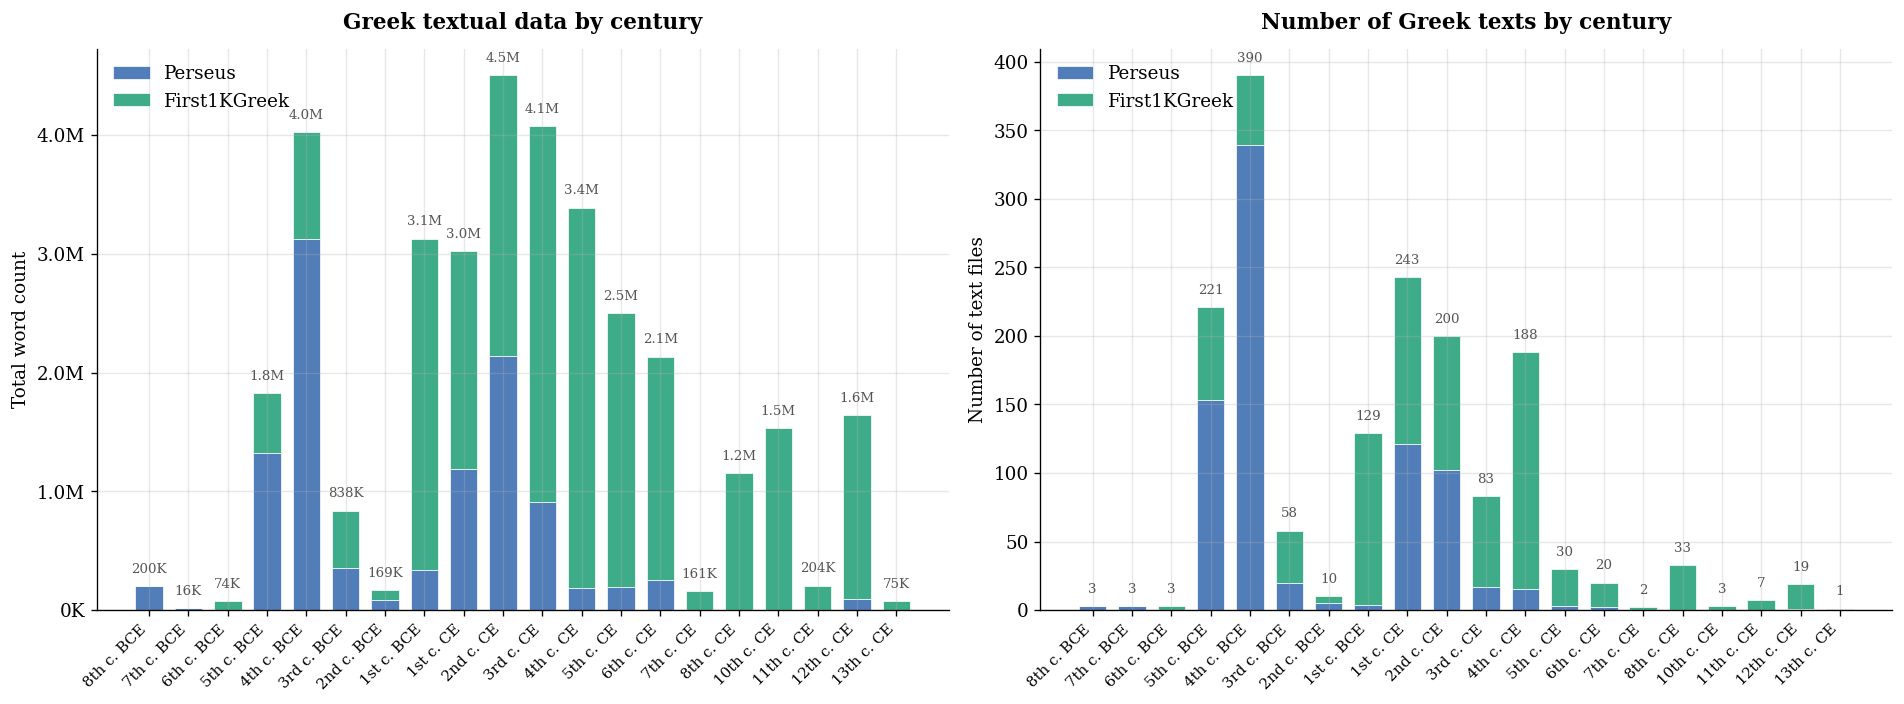

Saved: 01_textual_data_by_century.png


In [7]:
# Aggregate word counts by century and repo
pivot_words = df_dated.pivot_table(
    index='century',
    columns='repo',
    values='word_count',
    aggfunc='sum',
    fill_value=0,
).reindex(century_order, fill_value=0)

# Also count number of texts per century
pivot_texts = df_dated.pivot_table(
    index='century',
    columns='repo',
    values='file',
    aggfunc='count',
    fill_value=0,
).reindex(century_order, fill_value=0)

# ---- Plot: Word count by century (stacked by repo) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: word counts
colors = {'Perseus': '#3266ad', 'First1KGreek': '#1D9E75'}
x = np.arange(len(century_order))
width = 0.7

bottom = np.zeros(len(century_order))
for repo in ['Perseus', 'First1KGreek']:
    if repo in pivot_words.columns:
        vals = pivot_words[repo].values
        ax1.bar(x, vals, width, bottom=bottom, label=repo,
                color=colors.get(repo, '#888'), alpha=0.85, edgecolor='white', linewidth=0.5)
        bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels(century_labels_ordered, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Total word count')
ax1.set_title('Greek textual data by century', fontsize=13, fontweight='bold', pad=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
ax1.legend(frameon=False, loc='upper left')

# Annotate total on each bar
totals = pivot_words.sum(axis=1).reindex(century_order, fill_value=0)
for i, total in enumerate(totals):
    if total > 0:
        label = f'{total/1e6:.1f}M' if total >= 1e6 else f'{total/1e3:.0f}K'
        ax1.text(i, total + totals.max() * 0.02, label,
                 ha='center', va='bottom', fontsize=8, color='#555')

# Right panel: number of texts
bottom2 = np.zeros(len(century_order))
for repo in ['Perseus', 'First1KGreek']:
    if repo in pivot_texts.columns:
        vals = pivot_texts[repo].values
        ax2.bar(x, vals, width, bottom=bottom2, label=repo,
                color=colors.get(repo, '#888'), alpha=0.85, edgecolor='white', linewidth=0.5)
        bottom2 += vals

ax2.set_xticks(x)
ax2.set_xticklabels(century_labels_ordered, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Number of text files')
ax2.set_title('Number of Greek texts by century', fontsize=13, fontweight='bold', pad=12)
ax2.legend(frameon=False, loc='upper left')

# Annotate totals
totals2 = pivot_texts.sum(axis=1).reindex(century_order, fill_value=0)
for i, total in enumerate(totals2):
    if total > 0:
        ax2.text(i, total + totals2.max() * 0.02, str(int(total)),
                 ha='center', va='bottom', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('01_textual_data_by_century.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_textual_data_by_century.png")

## 8. Visualization 2: Prose vs. Poetry by Century

A stacked percentage bar chart showing the proportion of prose, poetry, and mixed
texts per century (by word count).

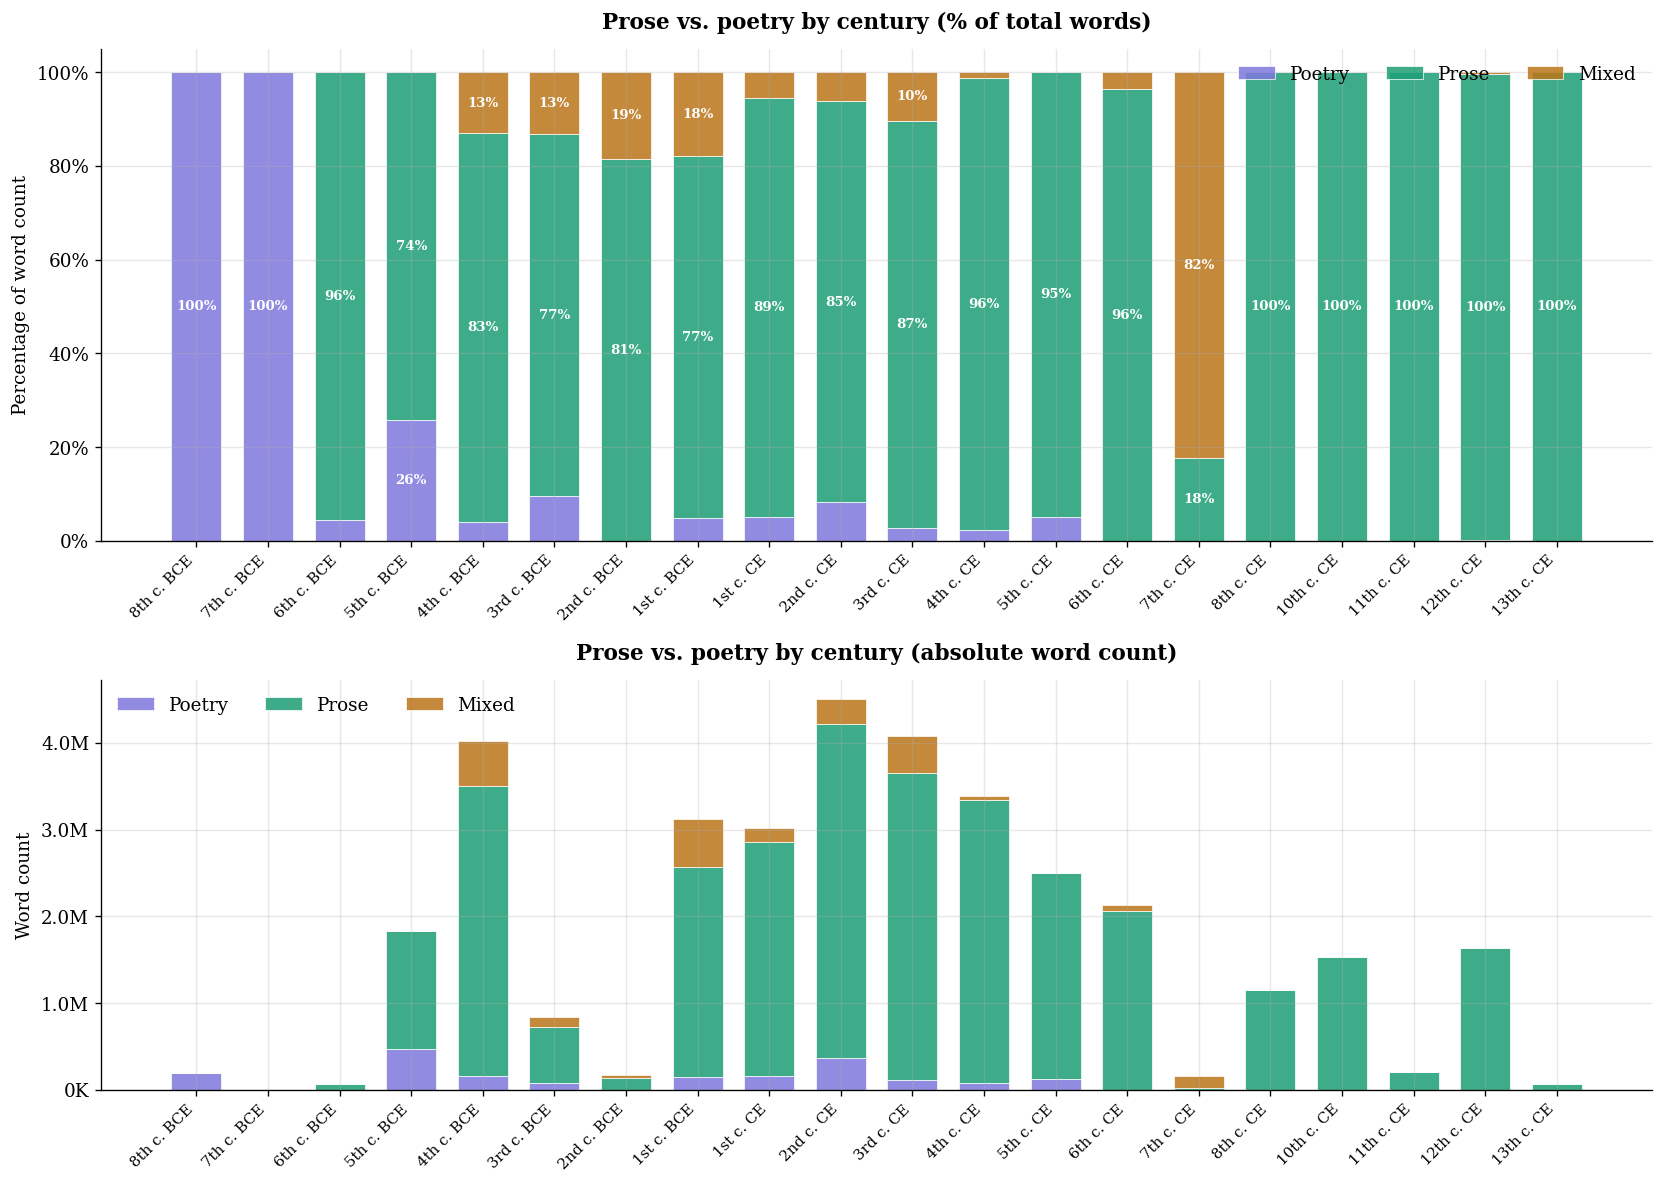

Saved: 02_prose_vs_poetry_by_century.png


In [8]:
# Aggregate by century and genre
genre_pivot = df_dated.pivot_table(
    index='century',
    columns='genre',
    values='word_count',
    aggfunc='sum',
    fill_value=0,
).reindex(century_order, fill_value=0)

# Ensure all genre columns exist
for g in ['prose', 'poetry', 'mixed']:
    if g not in genre_pivot.columns:
        genre_pivot[g] = 0

# Compute percentages
genre_totals = genre_pivot.sum(axis=1)
genre_pct = genre_pivot.div(genre_totals, axis=0) * 100
genre_pct = genre_pct.fillna(0)

# ---- Plot: percentage stacked bars ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.2, 1]})

genre_colors = {'poetry': '#7F77DD', 'prose': '#1D9E75', 'mixed': '#BA7517'}
x = np.arange(len(century_order))
width = 0.7

# Top panel: percentage stacked bar
bottom = np.zeros(len(century_order))
for genre in ['poetry', 'prose', 'mixed']:
    vals = genre_pct[genre].values
    bars = ax1.bar(x, vals, width, bottom=bottom, label=genre.capitalize(),
                   color=genre_colors[genre], alpha=0.85, edgecolor='white', linewidth=0.5)
    
    # Add percentage labels on segments >= 10%
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 10:
            ax1.text(i, b + v/2, f'{v:.0f}%',
                     ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels(century_labels_ordered, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Percentage of word count')
ax1.set_title('Prose vs. poetry by century (% of total words)', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylim(0, 105)
ax1.legend(frameon=False, loc='upper right', ncol=3)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter())

# Bottom panel: absolute word counts by genre
bottom = np.zeros(len(century_order))
for genre in ['poetry', 'prose', 'mixed']:
    vals = genre_pivot[genre].values
    ax2.bar(x, vals, width, bottom=bottom, label=genre.capitalize(),
            color=genre_colors[genre], alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(century_labels_ordered, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Word count')
ax2.set_title('Prose vs. poetry by century (absolute word count)', fontsize=13, fontweight='bold', pad=12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
ax2.legend(frameon=False, loc='upper left', ncol=3)

plt.tight_layout()
plt.savefig('02_prose_vs_poetry_by_century.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_prose_vs_poetry_by_century.png")

## 9. Summary Table

A compact table showing the data by century with word counts and genre breakdown.

In [9]:
# Build summary DataFrame
summary_rows = []
for c in century_order:
    mask = df_dated['century'] == c
    sub = df_dated[mask]
    total_words = sub['word_count'].sum()
    n_texts = len(sub)
    poetry_words = sub[sub['genre'] == 'poetry']['word_count'].sum()
    prose_words = sub[sub['genre'] == 'prose']['word_count'].sum()
    mixed_words = sub[sub['genre'] == 'mixed']['word_count'].sum()
    
    summary_rows.append({
        'Century': century_label(c),
        'Period': (
            'Archaic' if c <= -6 else
            'Classical' if c <= -4 else
            'Hellenistic' if c <= -1 else
            'Early Imperial' if c <= 2 else
            'Late Antique'
        ),
        'Texts': n_texts,
        'Total words': f'{total_words:,}',
        'Poetry %': f'{poetry_words/total_words*100:.1f}%' if total_words > 0 else '—',
        'Prose %': f'{prose_words/total_words*100:.1f}%' if total_words > 0 else '—',
        'Mixed %': f'{mixed_words/total_words*100:.1f}%' if total_words > 0 else '—',
        'Top authors': ', '.join(
            sub.groupby('author')['word_count'].sum()
               .nlargest(3).index.tolist()
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,Century,Period,Texts,Total words,Poetry %,Prose %,Mixed %,Top authors
0,8th c. BCE,Archaic,3,"199,823",100.0%,0.0%,0.0%,Homer
1,7th c. BCE,Archaic,3,"16,193",100.0%,0.0%,0.0%,Hesiod
2,6th c. BCE,Archaic,3,"74,198",4.5%,95.5%,0.0%,"Aesop, Batrachomyomachia"
3,5th c. BCE,Classical,221,"1,828,485",25.9%,74.1%,0.0%,"Hippocrates, Dionysius of Halicarnassus, Herodotus"
4,4th c. BCE,Classical,390,"4,026,249",4.1%,82.8%,13.1%,"Aristotle, Plutarch, Plato"
5,3rd c. BCE,Hellenistic,58,"838,063",9.5%,77.4%,13.1%,"Euclid, Chrysippus, Diogenes Laertius"
6,2nd c. BCE,Hellenistic,10,"168,958",0.0%,81.5%,18.5%,"Epictetus, Hipparchus, Theodosius of Bithynia"
7,1st c. BCE,Hellenistic,129,"3,126,370",4.8%,77.4%,17.8%,"Galen, Strabo, Theophrastus"
8,1st c. CE,Early Imperial,243,"3,022,033",5.2%,89.3%,5.5%,"Septuaginta, Flavius Josephus, Herodianus"
9,2nd c. CE,Early Imperial,200,"4,501,832",8.3%,85.5%,6.2%,"Philo Judaeus, Athenaeus, Diodorus Siculus"


## 9b. Poetry Lines Embedded in Prose Texts

Many prose works quote or embed verse lines (marked with `<l>` in TEI XML).
This section re-parses prose-classified texts to count those embedded verse lines,
revealing how much poetic material is woven into the prose tradition.
We report per-work counts and then aggregate summaries by century and author.

Prose texts to scan: 1370

Prose texts containing embedded verse lines: 354 of 1370 (25.8%)
Total embedded verse lines across all prose texts: 7,453

── Per-work counts (prose texts with embedded verse lines) ──


,Author,File,Century,Word count,Embedded verse lines,Repo
0,Pausanias,tlg0525.tlg001.perseus-grc2.xml,2nd c. CE,"217,618",451,Perseus
1,Sextus Empiricus,tlg0544.tlg002.1st1K-grc1.xml,2nd c. CE,"166,029",441,First1KGreek
2,Simplicius,tlg4013.tlg004.1st1K-grc1.xml,6th c. CE,"493,594",360,First1KGreek
3,Aelius Herodianus,tlg0087.tlg001.1st1K-grc1.xml,1st c. CE,"136,723",282,First1KGreek
4,Hippolytus,tlg2115.tlg060.opp-grc1.xml,3rd c. CE,"90,083",211,First1KGreek
5,Maximus of Tyre,tlg0563.tlg001.1st1K-grc1.xml,2nd c. CE,"97,637",204,First1KGreek
6,Herodotus,tlg0016.tlg001.perseus-grc2.xml,5th c. BCE,"184,922",151,Perseus
7,Aristotle,tlg0086.tlg038.perseus-grc2.xml,4th c. BCE,"43,177",147,Perseus
8,Eusebius,tlg2018.tlg005.1st1K-grc1.xml,3rd c. CE,"156,444",130,First1KGreek
9,Gelasius,tlg2768.tlg001.1st1K-grc1.xml,4th c. CE,"57,199",120,First1KGreek



── Summary by century ──


,prose_texts_with_verse,total_verse_lines,mean_verse_lines,max_verse_lines,total_prose_texts,pct_with_verse
6th c. BCE,1,5,5.0,5,2,50.0%
5th c. BCE,6,254,42.3,151,130,4.6%
4th c. BCE,105,"1,216",11.6,147,324,32.4%
3rd c. BCE,6,51,8.5,25,39,15.4%
2nd c. BCE,0,0,0.0,0,9,0.0%
1st c. BCE,24,200,8.3,38,117,20.5%
1st c. CE,64,"1,693",26.5,282,212,30.2%
2nd c. CE,45,"1,803",40.1,451,181,24.9%
3rd c. CE,16,498,31.1,211,73,21.9%
4th c. CE,43,472,11.0,120,174,24.7%



── Top 20 authors by embedded verse lines in prose ──


,prose_works,total_verse_lines,mean_per_work,total_words,lines_per_10k_words
author,,,,,
Septuaginta,20,815,40.8,"504,789",16.1
Sextus Empiricus,2,546,273.0,"221,578",24.6
Plutarch,60,503,8.4,"517,257",9.7
Simplicius,4,490,122.5,"1,140,771",4.3
Pausanias,1,451,451.0,"217,618",20.7
Unknown,13,404,31.1,"119,158",33.9
Aristotle,15,396,26.4,"474,822",8.3
Aelius Herodianus,1,282,282.0,"136,723",20.6
Hippolytus,1,211,211.0,"90,083",23.4


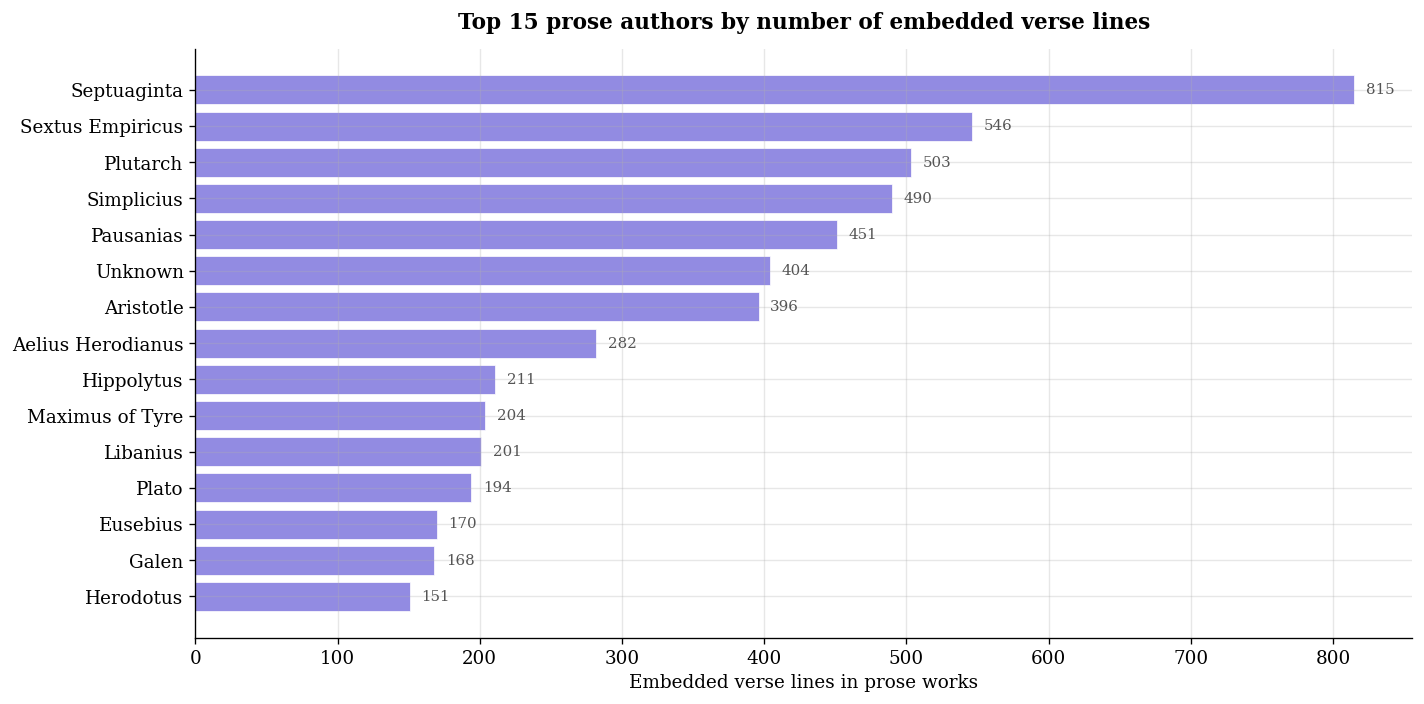

Saved: 03_verse_lines_in_prose.png


In [10]:
# ── Count <l> (verse-line) elements inside prose-classified texts ──

def count_verse_lines_in_file(filepath):
    """Parse a TEI XML file and return the number of <l> elements in the body."""
    try:
        tree = etree.parse(filepath)
    except etree.XMLSyntaxError:
        return 0
    root = tree.getroot()
    total = 0
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        total = len(root.findall(f'.//{ns_prefix}l'))
        if total > 0:
            break
    return total


def resolve_filepath(row):
    """Reconstruct the full path for a file from its basename and repo label."""
    if row['repo'] == 'Perseus':
        base = REPOS['perseus']['dir']
    else:
        base = REPOS['first1k']['dir']
    matches = glob.glob(os.path.join(base, 'data', '**', row['file']), recursive=True)
    return matches[0] if matches else None


# Subset: prose texts only
df_prose = df_dated[df_dated['genre'] == 'prose'].copy()
print(f"Prose texts to scan: {len(df_prose)}")

# Resolve full paths and count verse lines
df_prose['full_path'] = df_prose.apply(resolve_filepath, axis=1)
df_prose = df_prose.dropna(subset=['full_path'])
df_prose['verse_lines'] = df_prose['full_path'].apply(count_verse_lines_in_file)

# ── Per-work table (only works that actually contain verse lines) ──
df_with_verse = df_prose[df_prose['verse_lines'] > 0].copy()
df_with_verse = df_with_verse.sort_values('verse_lines', ascending=False)

print(f"\nProse texts containing embedded verse lines: "
      f"{len(df_with_verse)} of {len(df_prose)} "
      f"({len(df_with_verse)/len(df_prose)*100:.1f}%)")
print(f"Total embedded verse lines across all prose texts: "
      f"{df_with_verse['verse_lines'].sum():,}\n")

# Display the per-work table
per_work = df_with_verse[['author', 'file', 'century_label', 'word_count',
                          'verse_lines', 'repo']].copy()
per_work.columns = ['Author', 'File', 'Century', 'Word count',
                     'Embedded verse lines', 'Repo']
per_work = per_work.reset_index(drop=True)
print("── Per-work counts (prose texts with embedded verse lines) ──")
display(per_work.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th',
                            'props': [('text-align', 'left')]}])
        .format({'Word count': '{:,}'}))

# ── Summary by century ──
century_summary = (
    df_with_verse.groupby('century')
    .agg(
        prose_texts_with_verse=('file', 'count'),
        total_verse_lines=('verse_lines', 'sum'),
        mean_verse_lines=('verse_lines', 'mean'),
        max_verse_lines=('verse_lines', 'max'),
    )
    .reindex(century_order, fill_value=0)
)

# Add total prose texts per century for context
prose_per_century = df_prose.groupby('century')['file'].count()
century_summary['total_prose_texts'] = prose_per_century.reindex(century_order, fill_value=0)
century_summary['pct_with_verse'] = (
    century_summary['prose_texts_with_verse']
    / century_summary['total_prose_texts'].replace(0, float('nan')) * 100
)
century_summary.index = [century_label(c) for c in century_summary.index]
century_summary = century_summary[century_summary['total_prose_texts'] > 0]

print("\n── Summary by century ──")
display(century_summary.style.format({
    'total_verse_lines': '{:,.0f}',
    'mean_verse_lines': '{:.1f}',
    'max_verse_lines': '{:,.0f}',
    'pct_with_verse': '{:.1f}%',
}).set_properties(**{'text-align': 'left'}))

# ── Summary by author (top 20) ──
author_summary = (
    df_with_verse.groupby('author')
    .agg(
        prose_works=('file', 'count'),
        total_verse_lines=('verse_lines', 'sum'),
        mean_per_work=('verse_lines', 'mean'),
        total_words=('word_count', 'sum'),
    )
    .sort_values('total_verse_lines', ascending=False)
)
author_summary['lines_per_10k_words'] = (
    author_summary['total_verse_lines']
    / author_summary['total_words'] * 10_000
)

print("\n── Top 20 authors by embedded verse lines in prose ──")
display(author_summary.head(20).style.format({
    'total_verse_lines': '{:,}',
    'mean_per_work': '{:.1f}',
    'total_words': '{:,}',
    'lines_per_10k_words': '{:.1f}',
}).set_properties(**{'text-align': 'left'}))

# ── Quick bar chart ──
top_authors = author_summary.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_authors.index[::-1], top_authors['total_verse_lines'].values[::-1],
        color='#7F77DD', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Embedded verse lines in prose works')
ax.set_title('Top 15 prose authors by number of embedded verse lines',
             fontsize=13, fontweight='bold', pad=12)
for i, (v, name) in enumerate(zip(top_authors['total_verse_lines'].values[::-1],
                                   top_authors.index[::-1])):
    ax.text(v + top_authors['total_verse_lines'].max() * 0.01, i,
            f'{v:,}', va='center', fontsize=9, color='#555')
plt.tight_layout()
plt.savefig('03_verse_lines_in_prose.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_verse_lines_in_prose.png")


## 10. Undated Texts Report

Show which TLG codes weren't in our mapping so you can extend it.

In [11]:
undated = df[df['century'].isna() & (df['word_count'] > 0)].copy()

if len(undated) > 0:
    undated_summary = (
        undated.groupby(['tlg_code', 'author'])
        .agg(files=('file', 'count'), total_words=('word_count', 'sum'))
        .sort_values('total_words', ascending=False)
        .head(100)
    )
    print(f"Top 100 undated TLG codes (by word count) — add these to TLG_CENTURY_CLEAN:")
    print()
    for (tlg, author), row in undated_summary.iterrows():
        print(f"    '{tlg}': ??,   # {author} ({row['files']} files, {row['total_words']:,} words)")
else:
    print("All texts with content have century assignments!")

Top 100 undated TLG codes (by word count) — add these to TLG_CENTURY_CLEAN:

    '7000': ??,   # Unknown (5 files, 136,416 words)
    '4033': ??,   # Anonymi In Aristotelis Ethica Nicomachea (1 files, 100,139 words)
    '4026': ??,   # Anonymi in Aristotelis Artem Rhetoricam (3 files, 98,702 words)
    '0530': ??,   # Pseudo-Galen (6 files, 91,320 words)
    '5037': ??,   # Scholia in Sophoclem (1 files, 79,535 words)
    '1551': ??,   # Oracula Sibyllina (2 files, 57,155 words)
    '5029': ??,   # Scholia in Lucianum (1 files, 52,210 words)
    '1286': ??,   # Anonymous (18 files, 39,677 words)
    '4027': ??,   # Anonymi in Aristotelis Categorias (1 files, 38,256 words)
    '5031': ??,   # Scholia in Nicandrum (2 files, 33,854 words)
    '5022': ??,   # Scholia in Euclidem (6 files, 33,339 words)
    '4193': ??,   # Anonymi in Aristotelis Sophisticos Elenchos (1 files, 31,186 words)
    '1482': ??,   # Cyranides (1 files, 24,199 words)
    '9004': ??,   # Anonymi In Aristotelis Libru

## 11. Implications for Diachronic Study

Key observations to interpret from the visualizations:

1. **Corpus imbalance matters.** The 5th–4th centuries BCE and 2nd century CE
   are likely the best-represented. Any frequency-based diachronic claims must
   be normalized against the available corpus size per period.

2. **Genre shift over time.** The Archaic period is overwhelmingly poetry (Homer,
   Hesiod, lyric). Prose emerges in the 5th century (Herodotus, Thucydides,
   Hippocratic corpus) and dominates from the Hellenistic period onward.
   This is a real historical development, but it also means that apparent
   "linguistic change" might partly reflect genre differences.

3. **Control for genre in diachronic comparisons.** When comparing, e.g.,
   particle usage in 5th c. BCE vs. 2nd c. CE, restrict the comparison to
   prose-only or poetry-only subcorpora, not the full mixed data.

4. **First1KGreek fills critical gaps.** It adds substantial late antique
   material (church fathers, commentators) that Perseus underrepresents,
   which is essential for tracking Koine and post-Classical developments.

## 9c. Quotation Tags in Prose Texts: `<quote>` vs. `<said>` / `<q>`

TEI XML distinguishes between different kinds of quoted material:

- **`<quote>`** — text taken from *another* document (an external citation).
- **`<said>`** and **`<q>`** — direct or reported speech attributed to a character
  or speaker *within* the narrative (i.e., the document author's own composition).

This section counts how many works use each tag type, how frequently,
and summarises the results by century and author.

Scanning 1646 texts for quotation tags...

── Overall tag usage across 1646 dated texts ──
  Works using <quote>          :   431  (26.2%)
  Works using <said> or <q>     :   469  (28.5%)
  Works using both              :   293  (17.8%)
  Works using neither           :  1039  (63.1%)

  Total <quote> occurrences     :   26,324
  Total <said>/<q> occurrences  :   59,682

── Per-work counts (607 texts with quotation tags) ──


,Author,File,Genre,Century,,,,Word count
0,Nonnus of Panopolis,tlg2045.tlg001.perseus-grc2.xml,poetry,5th c. CE,0,0,"7,960","127,720"
1,Athenaeus,tlg0008.tlg001.perseus-grc4.xml,prose,2nd c. CE,"5,334",0,6,"265,746"
2,Athenaeus,tlg0008.tlg001.perseus-grc3.xml,poetry,2nd c. CE,"3,126",0,0,"265,096"
3,Scholia in Euripidem,tlg5023.tlg016.1st1K-grc1.xml,prose,12th c. CE,"2,640",0,209,"74,018"
4,Scholia in Euripidem,tlg5023.tlg015.1st1K-grc1.xml,prose,12th c. CE,"2,504",0,230,"73,533"
5,Clement of Alexandria,tlg0555.tlg004.perseus-grc1.xml,prose,3rd c. CE,377,0,"2,308","133,497"
6,Philostratus the Athenian,tlg0638.tlg001.perseus-grc2.xml,prose,3rd c. CE,14,0,"2,081","83,893"
7,Quintus Smyrnaeus,tlg2046.tlg001.perseus-grc2.xml,poetry,4th c. CE,0,0,"2,083","60,209"
8,Plato,tlg0059.tlg034.perseus-grc2.xml,prose,4th c. BCE,17,"1,999",50,"104,683"
9,Diogenes Laertius,tlg0004.tlg001.perseus-grc2.xml,mixed,3rd c. BCE,342,0,"1,344","110,055"



── Quotation tag usage by century ──


,total_texts,texts_with_quote,texts_with_said_q,texts_with_both,sum_quote,sum_said_q,pct_quote,pct_said_q
8th c. BCE,3,0,2,0,0,"1,370",0.0%,66.7%
7th c. BCE,3,0,0,0,0,0,0.0%,0.0%
6th c. BCE,3,0,1,0,0,389,0.0%,33.3%
5th c. BCE,221,14,50,9,332,"2,327",6.3%,22.6%
4th c. BCE,390,199,234,175,"2,709","26,381",51.0%,60.0%
3rd c. BCE,58,7,24,7,452,"3,307",12.1%,41.4%
2nd c. BCE,10,3,3,2,202,"1,087",30.0%,30.0%
1st c. BCE,129,19,7,5,"2,588",855,14.7%,5.4%
1st c. CE,243,79,64,46,"3,012","2,826",32.5%,26.3%
2nd c. CE,200,56,39,27,"9,144","1,577",28.0%,19.5%



── Quotation tag usage by genre ──


,total_texts,texts_with_quote,texts_with_said_q,sum_quote,sum_said_q,pct_quote,pct_said_q
genre,,,,,,,
mixed,108,56,49,"2,167","5,775",51.9%,45.4%
poetry,168,23,65,"3,911","13,894",13.7%,38.7%
prose,1370,352,355,"20,246","40,013",25.7%,25.9%


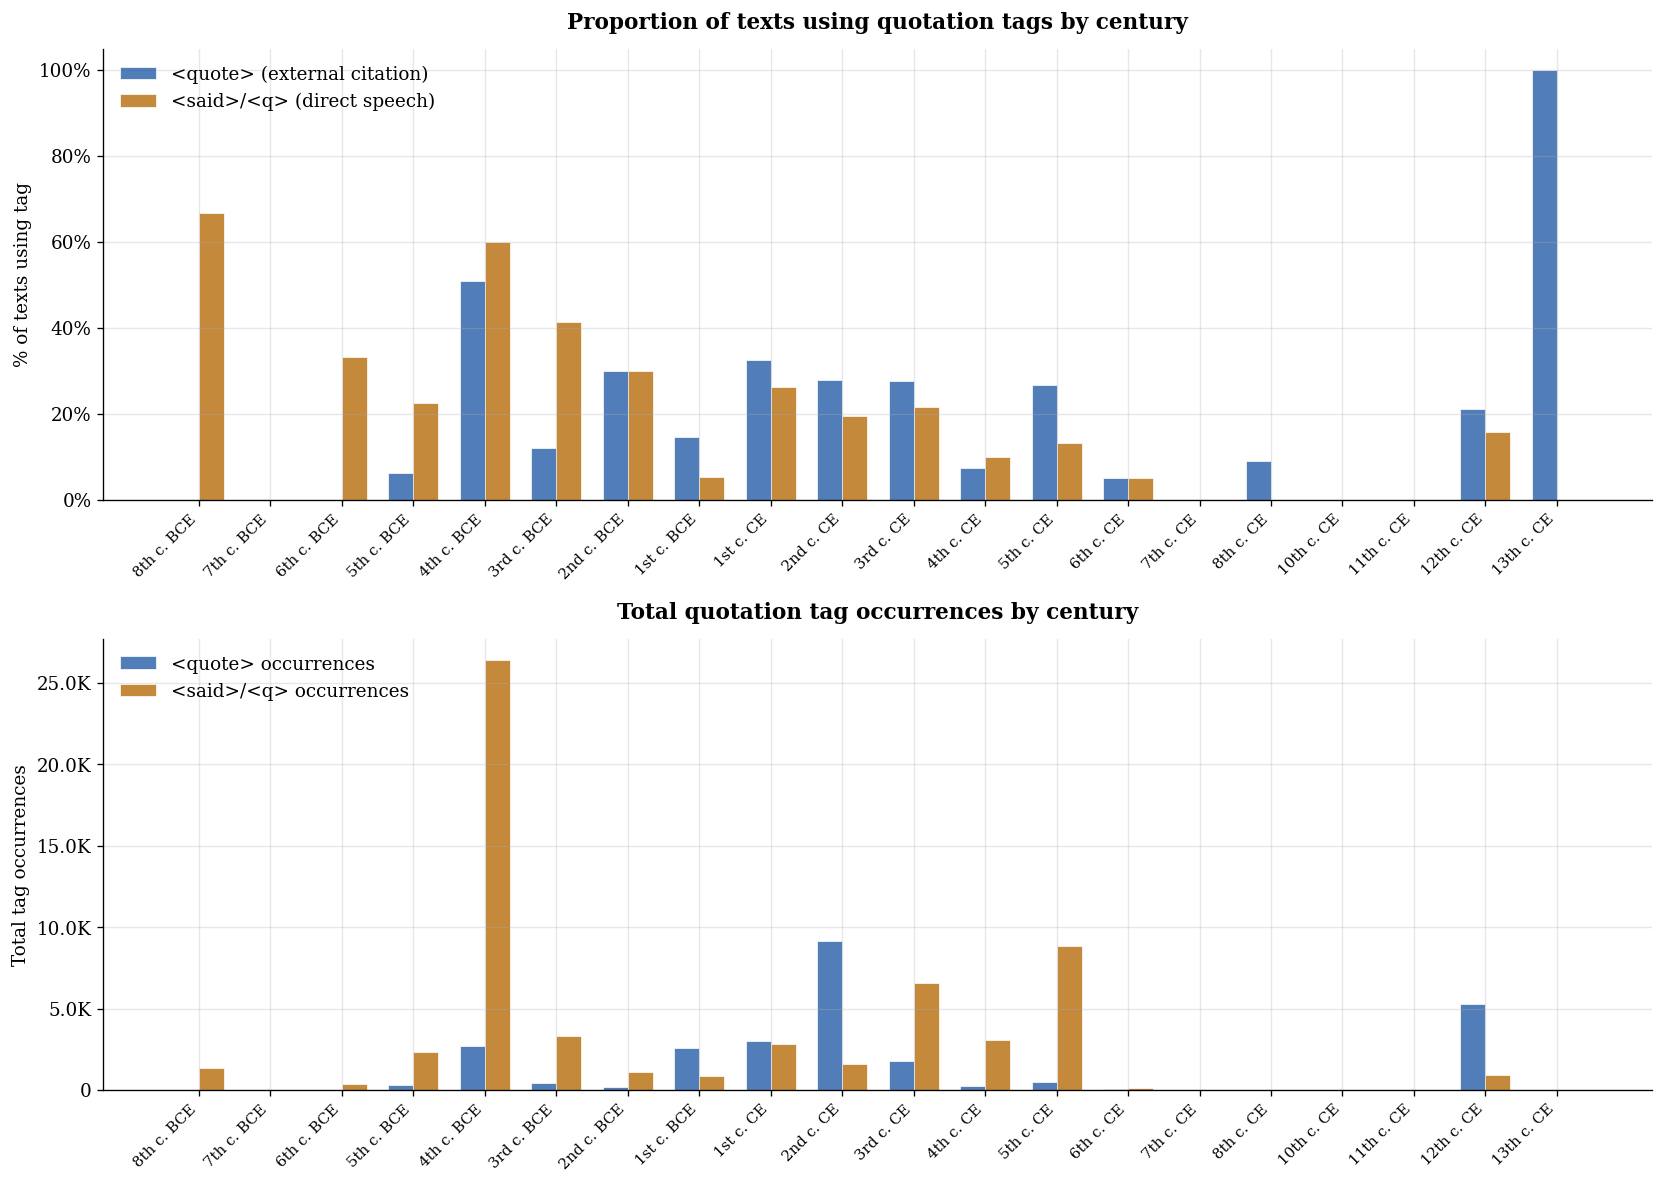

Saved: 04_quotation_tags_by_century.png


In [12]:
# ── Count <quote>, <said>, and <q> elements in each text ──

def count_quotation_tags(filepath):
    """Parse a TEI XML file and return counts of <quote>, <said>, and <q>.

    Returns a dict with keys 'quote', 'said', 'q'.
    """
    counts = {'quote': 0, 'said': 0, 'q': 0}
    try:
        tree = etree.parse(filepath)
    except etree.XMLSyntaxError:
        return counts
    root = tree.getroot()

    # Find the body to exclude header metadata
    body = None
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        body = root.find(f'.//{ns_prefix}body')
        if body is not None:
            break
    if body is None:
        for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
            body = root.find(f'.//{ns_prefix}text')
            if body is not None:
                break
    if body is None:
        return counts

    for tag in ['quote', 'said', 'q']:
        for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
            n = len(body.findall(f'.//{ns_prefix}{tag}'))
            if n > 0:
                counts[tag] = n
                break
    return counts


# Resolve paths for all dated texts (not just prose this time)
df_qt = df_dated.copy()
if 'full_path' not in df_qt.columns:
    df_qt['full_path'] = df_qt.apply(resolve_filepath, axis=1)
df_qt = df_qt.dropna(subset=['full_path'])

print(f"Scanning {len(df_qt)} texts for quotation tags...")
qt_counts = df_qt['full_path'].apply(count_quotation_tags)
df_qt['n_quote'] = qt_counts.apply(lambda d: d['quote'])
df_qt['n_said']  = qt_counts.apply(lambda d: d['said'])
df_qt['n_q']     = qt_counts.apply(lambda d: d['q'])
df_qt['n_said_q'] = df_qt['n_said'] + df_qt['n_q']

# Boolean flags
df_qt['has_quote']  = df_qt['n_quote'] > 0
df_qt['has_said_q'] = df_qt['n_said_q'] > 0
df_qt['has_both']   = df_qt['has_quote'] & df_qt['has_said_q']

# ── Overall summary ──
n = len(df_qt)
n_quote  = df_qt['has_quote'].sum()
n_said_q = df_qt['has_said_q'].sum()
n_both   = df_qt['has_both'].sum()
n_either = (df_qt['has_quote'] | df_qt['has_said_q']).sum()
n_neither = n - n_either

print(f"\n── Overall tag usage across {n} dated texts ──")
print(f"  Works using <quote>          : {n_quote:>5}  ({n_quote/n*100:.1f}%)")
print(f"  Works using <said> or <q>     : {n_said_q:>5}  ({n_said_q/n*100:.1f}%)")
print(f"  Works using both              : {n_both:>5}  ({n_both/n*100:.1f}%)")
print(f"  Works using neither           : {n_neither:>5}  ({n_neither/n*100:.1f}%)")
print(f"\n  Total <quote> occurrences     : {df_qt['n_quote'].sum():>8,}")
print(f"  Total <said>/<q> occurrences  : {df_qt['n_said_q'].sum():>8,}")

# ── Per-work table: works with any quotation tags, sorted by total ──
df_qt['total_qt_tags'] = df_qt['n_quote'] + df_qt['n_said_q']
df_qt_any = df_qt[df_qt['total_qt_tags'] > 0].sort_values(
    'total_qt_tags', ascending=False
).copy()

per_work_qt = df_qt_any[['author', 'file', 'genre', 'century_label',
                          'n_quote', 'n_said', 'n_q', 'word_count']].copy()
per_work_qt.columns = ['Author', 'File', 'Genre', 'Century',
                        '<quote>', '<said>', '<q>', 'Word count']
per_work_qt = per_work_qt.reset_index(drop=True)

print(f"\n── Per-work counts ({len(per_work_qt)} texts with quotation tags) ──")
display(per_work_qt.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th',
                            'props': [('text-align', 'left')]}])
        .format({'Word count': '{:,}', '<quote>': '{:,}',
                 '<said>': '{:,}', '<q>': '{:,}'}))

# ── Summary by century ──
cent_qt = df_qt.groupby('century').agg(
    total_texts=('file', 'count'),
    texts_with_quote=('has_quote', 'sum'),
    texts_with_said_q=('has_said_q', 'sum'),
    texts_with_both=('has_both', 'sum'),
    sum_quote=('n_quote', 'sum'),
    sum_said_q=('n_said_q', 'sum'),
).reindex(century_order, fill_value=0)

cent_qt['pct_quote']  = cent_qt['texts_with_quote']  / cent_qt['total_texts'] * 100
cent_qt['pct_said_q'] = cent_qt['texts_with_said_q'] / cent_qt['total_texts'] * 100
cent_qt.index = [century_label(c) for c in cent_qt.index]
cent_qt = cent_qt[cent_qt['total_texts'] > 0]

print("\n── Quotation tag usage by century ──")
display(cent_qt.style.format({
    'sum_quote': '{:,}', 'sum_said_q': '{:,}',
    'pct_quote': '{:.1f}%', 'pct_said_q': '{:.1f}%',
}).set_properties(**{'text-align': 'left'}))

# ── Summary by genre ──
genre_qt = df_qt.groupby('genre').agg(
    total_texts=('file', 'count'),
    texts_with_quote=('has_quote', 'sum'),
    texts_with_said_q=('has_said_q', 'sum'),
    sum_quote=('n_quote', 'sum'),
    sum_said_q=('n_said_q', 'sum'),
)
genre_qt['pct_quote']  = genre_qt['texts_with_quote']  / genre_qt['total_texts'] * 100
genre_qt['pct_said_q'] = genre_qt['texts_with_said_q'] / genre_qt['total_texts'] * 100

print("\n── Quotation tag usage by genre ──")
display(genre_qt.style.format({
    'sum_quote': '{:,}', 'sum_said_q': '{:,}',
    'pct_quote': '{:.1f}%', 'pct_said_q': '{:.1f}%',
}).set_properties(**{'text-align': 'left'}))

# ── Visualization: grouped bar chart by century ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [1, 1]})

# Top: percentage of texts using each tag type
cent_plot = cent_qt.copy()
x = np.arange(len(cent_plot))
w = 0.35
ax1.bar(x - w/2, cent_plot['pct_quote'],  w, label='<quote> (external citation)',
        color='#3266ad', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.bar(x + w/2, cent_plot['pct_said_q'], w, label='<said>/<q> (direct speech)',
        color='#BA7517', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(cent_plot.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('% of texts using tag')
ax1.set_title('Proportion of texts using quotation tags by century',
              fontsize=13, fontweight='bold', pad=12)
ax1.legend(frameon=False, loc='upper left')
ax1.yaxis.set_major_formatter(ticker.PercentFormatter())

# Bottom: total tag occurrences
ax2.bar(x - w/2, cent_plot['sum_quote'],  w, label='<quote> occurrences',
        color='#3266ad', alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.bar(x + w/2, cent_plot['sum_said_q'], w, label='<said>/<q> occurrences',
        color='#BA7517', alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(cent_plot.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Total tag occurrences')
ax2.set_title('Total quotation tag occurrences by century',
              fontsize=13, fontweight='bold', pad=12)
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f'{v/1e3:.1f}K' if v >= 1e3 else f'{v:.0f}')
)
ax2.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('04_quotation_tags_by_century.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_quotation_tags_by_century.png")

Scanning 1646 texts for quotation tags...

── Overall tag usage across 1646 dated texts ──
  Works using <quote>          :   431  (26.2%)
  Works using <said> or <q>     :   469  (28.5%)
  Works using both              :   293  (17.8%)
  Works using neither           :  1039  (63.1%)

  Total <quote> occurrences     :   26,324
  Total <said>/<q> occurrences  :   59,682

  Words inside <quote> tags     :  579,302  (1.7% of corpus)
  Words inside <said>/<q> tags  : 1,481,337  (4.3% of corpus)

── Per-work counts (607 texts with quotation tags) ──


,Author,File,Genre,Century,`` tags,Words in `\`,\ tags,\ tags,Words in `\`/`\`,Total words,% in \,% in \/\
0,Nonnus of Panopolis,tlg2045.tlg001.perseus-grc2.xml,poetry,5th c. CE,0,0,0,7960,49441,"127,720",0.000000,38.710460
1,Athenaeus,tlg0008.tlg001.perseus-grc4.xml,prose,2nd c. CE,"5,334",249216,0,6,32,"265,746",93.779775,0.012042
2,Athenaeus,tlg0008.tlg001.perseus-grc3.xml,poetry,2nd c. CE,"3,126",64722,0,0,0,"265,096",24.414552,0.000000
3,Scholia in Euripidem,tlg5023.tlg016.1st1K-grc1.xml,prose,12th c. CE,"2,640",5870,0,209,1231,"74,018",7.930503,1.663109
4,Scholia in Euripidem,tlg5023.tlg015.1st1K-grc1.xml,prose,12th c. CE,"2,504",4947,0,230,1249,"73,533",6.727592,1.698557
5,Clement of Alexandria,tlg0555.tlg004.perseus-grc1.xml,prose,3rd c. CE,377,5621,0,2308,27850,"133,497",4.210582,20.861892
6,Philostratus the Athenian,tlg0638.tlg001.perseus-grc2.xml,prose,3rd c. CE,14,161,0,2081,45474,"83,893",0.191911,54.204761
7,Quintus Smyrnaeus,tlg2046.tlg001.perseus-grc2.xml,poetry,4th c. CE,0,0,0,2083,14579,"60,209",0.000000,24.213988
8,Plato,tlg0059.tlg034.perseus-grc2.xml,prose,4th c. BCE,17,232,1999,50,106921,"104,683",0.221621,102.137883
9,Diogenes Laertius,tlg0004.tlg001.perseus-grc2.xml,mixed,3rd c. BCE,342,6268,0,1344,21629,"110,055",5.695334,19.652901



── Quotation tag usage by century ──


,total_texts,texts_with_quote,texts_with_said_q,texts_with_both,sum_quote,sum_said_q,sum_quote_words,sum_said_q_words,sum_total_words,pct_quote,pct_said_q,pct_words_in_quote,pct_words_in_said_q
8th c. BCE,3,0,2,0,0,"1,370",0,"117,451","199,823",0.0%,66.7%,0.0%,58.8%
7th c. BCE,3,0,0,0,0,0,0,0,"16,193",0.0%,0.0%,0.0%,0.0%
6th c. BCE,3,0,1,0,0,389,0,"5,726","74,198",0.0%,33.3%,0.0%,7.7%
5th c. BCE,221,14,50,9,332,"2,327","6,994","60,396","1,828,485",6.3%,22.6%,0.4%,3.3%
4th c. BCE,390,199,234,175,"2,709","26,381","38,342","848,407","4,026,249",51.0%,60.0%,1.0%,21.1%
3rd c. BCE,58,7,24,7,452,"3,307","7,872","41,825","838,063",12.1%,41.4%,0.9%,5.0%
2nd c. BCE,10,3,3,2,202,"1,087","20,487","10,257","168,958",30.0%,30.0%,12.1%,6.1%
1st c. BCE,129,19,7,5,"2,588",855,"80,784","8,183","3,126,370",14.7%,5.4%,2.6%,0.3%
1st c. CE,243,79,64,46,"3,012","2,826","18,636","72,406","3,022,033",32.5%,26.3%,0.6%,2.4%
2nd c. CE,200,56,39,27,"9,144","1,577","335,872","32,383","4,501,832",28.0%,19.5%,7.5%,0.7%



── Quotation tag usage by genre ──


,total_texts,texts_with_quote,texts_with_said_q,sum_quote,sum_said_q,sum_quote_words,sum_said_q_words,sum_total_words,pct_quote,pct_said_q,pct_words_in_quote,pct_words_in_said_q
genre,,,,,,,,,,,,
mixed,108,56,49,"2,167","5,775","25,872","311,057","2,347,460",51.9%,45.4%,1.1%,13.3%
poetry,168,23,65,"3,911","13,894","74,850","225,619","1,941,625",13.7%,38.7%,3.9%,11.6%
prose,1370,352,355,"20,246","40,013","478,580","944,661","30,371,541",25.7%,25.9%,1.6%,3.1%


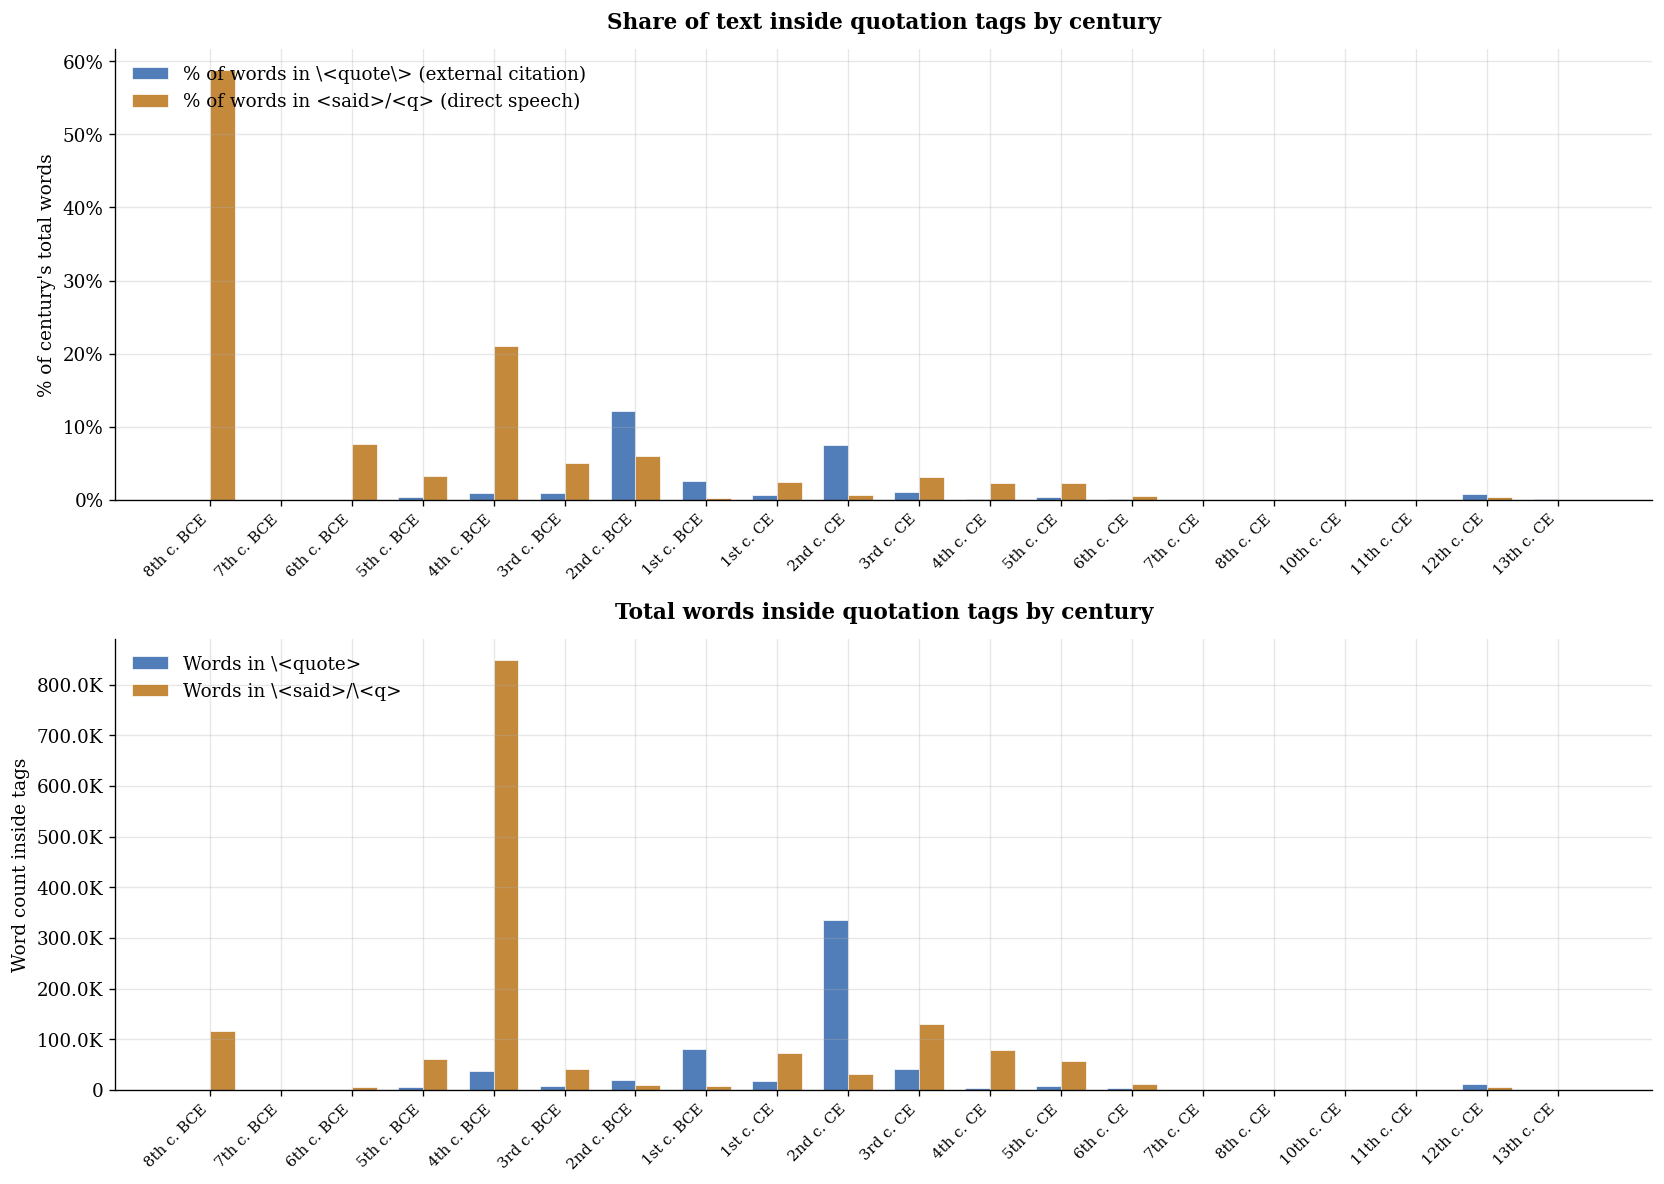

Saved: 04_quotation_tags_by_century.png


In [13]:
# ── Count <quote>, <said>, and <q> elements in each text ──

def count_quotation_tags(filepath):
    """Parse a TEI XML file and return counts and word counts for
    <quote>, <said>, and <q> elements.

    Returns a dict with keys:
      'quote', 'said', 'q'                    – element counts
      'quote_words', 'said_words', 'q_words'   – Greek word counts inside each
    """
    greek_pattern = re.compile(r'[\u0370-\u03FF\u1F00-\u1FFF]')
    counts = {'quote': 0, 'said': 0, 'q': 0,
              'quote_words': 0, 'said_words': 0, 'q_words': 0}
    try:
        tree = etree.parse(filepath)
    except etree.XMLSyntaxError:
        return counts
    root = tree.getroot()

    # Find the body to exclude header metadata
    body = None
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        body = root.find(f'.//{ns_prefix}body')
        if body is not None:
            break
    if body is None:
        for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
            body = root.find(f'.//{ns_prefix}text')
            if body is not None:
                break
    if body is None:
        return counts

    for tag in ['quote', 'said', 'q']:
        for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
            elements = body.findall(f'.//{ns_prefix}{tag}')
            if elements:
                counts[tag] = len(elements)
                words = 0
                for el in elements:
                    text = ''.join(el.itertext())
                    words += sum(1 for w in text.split()
                                 if greek_pattern.search(w))
                counts[f'{tag}_words'] = words
                break
    return counts


# Resolve paths for all dated texts (not just prose this time)
df_qt = df_dated.copy()
if 'full_path' not in df_qt.columns:
    df_qt['full_path'] = df_qt.apply(resolve_filepath, axis=1)
df_qt = df_qt.dropna(subset=['full_path'])

print(f"Scanning {len(df_qt)} texts for quotation tags...")
qt_counts = df_qt['full_path'].apply(count_quotation_tags)
df_qt['n_quote'] = qt_counts.apply(lambda d: d['quote'])
df_qt['n_said']  = qt_counts.apply(lambda d: d['said'])
df_qt['n_q']     = qt_counts.apply(lambda d: d['q'])
df_qt['n_said_q'] = df_qt['n_said'] + df_qt['n_q']

# Word counts inside each tag type
df_qt['words_in_quote']  = qt_counts.apply(lambda d: d['quote_words'])
df_qt['words_in_said']   = qt_counts.apply(lambda d: d['said_words'])
df_qt['words_in_q']      = qt_counts.apply(lambda d: d['q_words'])
df_qt['words_in_said_q'] = df_qt['words_in_said'] + df_qt['words_in_q']

# Percentage of each work's text that lives inside quotation tags
df_qt['pct_quote_words']  = (
    df_qt['words_in_quote'] / df_qt['word_count'].replace(0, float('nan')) * 100
)
df_qt['pct_said_q_words'] = (
    df_qt['words_in_said_q'] / df_qt['word_count'].replace(0, float('nan')) * 100
)

# Boolean flags
df_qt['has_quote']  = df_qt['n_quote'] > 0
df_qt['has_said_q'] = df_qt['n_said_q'] > 0
df_qt['has_both']   = df_qt['has_quote'] & df_qt['has_said_q']

# ── Overall summary ──
n = len(df_qt)
n_quote  = df_qt['has_quote'].sum()
n_said_q = df_qt['has_said_q'].sum()
n_both   = df_qt['has_both'].sum()
n_either = (df_qt['has_quote'] | df_qt['has_said_q']).sum()
n_neither = n - n_either
total_words_all = df_qt['word_count'].sum()

print(f"\n── Overall tag usage across {n} dated texts ──")
print(f"  Works using <quote>          : {n_quote:>5}  ({n_quote/n*100:.1f}%)")
print(f"  Works using <said> or <q>     : {n_said_q:>5}  ({n_said_q/n*100:.1f}%)")
print(f"  Works using both              : {n_both:>5}  ({n_both/n*100:.1f}%)")
print(f"  Works using neither           : {n_neither:>5}  ({n_neither/n*100:.1f}%)")
print(f"\n  Total <quote> occurrences     : {df_qt['n_quote'].sum():>8,}")
print(f"  Total <said>/<q> occurrences  : {df_qt['n_said_q'].sum():>8,}")
print(f"\n  Words inside <quote> tags     : {df_qt['words_in_quote'].sum():>8,}  "
      f"({df_qt['words_in_quote'].sum()/total_words_all*100:.1f}% of corpus)")
print(f"  Words inside <said>/<q> tags  : {df_qt['words_in_said_q'].sum():>8,}  "
      f"({df_qt['words_in_said_q'].sum()/total_words_all*100:.1f}% of corpus)")

# ── Per-work table: works with any quotation tags, sorted by total ──
df_qt['total_qt_tags'] = df_qt['n_quote'] + df_qt['n_said_q']
df_qt_any = df_qt[df_qt['total_qt_tags'] > 0].sort_values(
    'total_qt_tags', ascending=False
).copy()

per_work_qt = df_qt_any[['author', 'file', 'genre', 'century_label',
                          'n_quote', 'words_in_quote',
                          'n_said', 'n_q', 'words_in_said_q',
                          'word_count',
                          'pct_quote_words', 'pct_said_q_words']].copy()
per_work_qt.columns = ['Author', 'File', 'Genre', 'Century',
                        '`<quote>` tags', 'Words in `\<quote\>`',
                        '\<said\> tags', '\<q\> tags', 'Words in `\<said\>`/`\<q\>`',
                        'Total words',
                        '% in \<quote\>', '% in \<said\>/\<q\>']
per_work_qt = per_work_qt.reset_index(drop=True)

print(f"\n── Per-work counts ({len(per_work_qt)} texts with quotation tags) ──")
display(per_work_qt.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th',
                            'props': [('text-align', 'left')]}])
        .format({'Total words': '{:,}',
                 '`<quote>` tags': '{:,}', 'Words in `<quote>`': '{:,}',
                 '`<said>` tags': '{:,}', '`<q>` tags': '{:,}',
                 'Words in `<said>`/`<q>`': '{:,}',
                 '% in `<quote>`': '{:.1f}%',
                 '% in `<said>`/`<q>`': '{:.1f}%'}))

# ── Summary by century ──
cent_qt = df_qt.groupby('century').agg(
    total_texts=('file', 'count'),
    texts_with_quote=('has_quote', 'sum'),
    texts_with_said_q=('has_said_q', 'sum'),
    texts_with_both=('has_both', 'sum'),
    sum_quote=('n_quote', 'sum'),
    sum_said_q=('n_said_q', 'sum'),
    sum_quote_words=('words_in_quote', 'sum'),
    sum_said_q_words=('words_in_said_q', 'sum'),
    sum_total_words=('word_count', 'sum'),
).reindex(century_order, fill_value=0)

cent_qt['pct_quote']  = cent_qt['texts_with_quote']  / cent_qt['total_texts'] * 100
cent_qt['pct_said_q'] = cent_qt['texts_with_said_q'] / cent_qt['total_texts'] * 100
cent_qt['pct_words_in_quote'] = (
    cent_qt['sum_quote_words'] / cent_qt['sum_total_words'].replace(0, float('nan')) * 100
)
cent_qt['pct_words_in_said_q'] = (
    cent_qt['sum_said_q_words'] / cent_qt['sum_total_words'].replace(0, float('nan')) * 100
)
cent_qt.index = [century_label(c) for c in cent_qt.index]
cent_qt = cent_qt[cent_qt['total_texts'] > 0]

print("\n── Quotation tag usage by century ──")
display(cent_qt.style.format({
    'sum_quote': '{:,}', 'sum_said_q': '{:,}',
    'sum_quote_words': '{:,}', 'sum_said_q_words': '{:,}',
    'sum_total_words': '{:,}',
    'pct_quote': '{:.1f}%', 'pct_said_q': '{:.1f}%',
    'pct_words_in_quote': '{:.1f}%', 'pct_words_in_said_q': '{:.1f}%',
}).set_properties(**{'text-align': 'left'}))

# ── Summary by genre ──
genre_qt = df_qt.groupby('genre').agg(
    total_texts=('file', 'count'),
    texts_with_quote=('has_quote', 'sum'),
    texts_with_said_q=('has_said_q', 'sum'),
    sum_quote=('n_quote', 'sum'),
    sum_said_q=('n_said_q', 'sum'),
    sum_quote_words=('words_in_quote', 'sum'),
    sum_said_q_words=('words_in_said_q', 'sum'),
    sum_total_words=('word_count', 'sum'),
)
genre_qt['pct_quote']  = genre_qt['texts_with_quote']  / genre_qt['total_texts'] * 100
genre_qt['pct_said_q'] = genre_qt['texts_with_said_q'] / genre_qt['total_texts'] * 100
genre_qt['pct_words_in_quote'] = (
    genre_qt['sum_quote_words'] / genre_qt['sum_total_words'].replace(0, float('nan')) * 100
)
genre_qt['pct_words_in_said_q'] = (
    genre_qt['sum_said_q_words'] / genre_qt['sum_total_words'].replace(0, float('nan')) * 100
)

print("\n── Quotation tag usage by genre ──")
display(genre_qt.style.format({
    'sum_quote': '{:,}', 'sum_said_q': '{:,}',
    'sum_quote_words': '{:,}', 'sum_said_q_words': '{:,}',
    'sum_total_words': '{:,}',
    'pct_quote': '{:.1f}%', 'pct_said_q': '{:.1f}%',
    'pct_words_in_quote': '{:.1f}%', 'pct_words_in_said_q': '{:.1f}%',
}).set_properties(**{'text-align': 'left'}))

# ── Visualization: grouped bar chart by century ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [1, 1]})

# Top: percentage of each century's words inside each tag type
cent_plot = cent_qt.copy()
x = np.arange(len(cent_plot))
w = 0.35
ax1.bar(x - w/2, cent_plot['pct_words_in_quote'],  w,
        label='% of words in \<quote\> (external citation)',
        color='#3266ad', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.bar(x + w/2, cent_plot['pct_words_in_said_q'], w,
        label='% of words in <said>/<q> (direct speech)',
        color='#BA7517', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(cent_plot.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('% of century\'s total words')
ax1.set_title('Share of text inside quotation tags by century',
              fontsize=13, fontweight='bold', pad=12)
ax1.legend(frameon=False, loc='upper left')
ax1.yaxis.set_major_formatter(ticker.PercentFormatter())

# Bottom: absolute word counts inside tags
ax2.bar(x - w/2, cent_plot['sum_quote_words'],  w,
        label='Words in \<quote>',
        color='#3266ad', alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.bar(x + w/2, cent_plot['sum_said_q_words'], w,
        label='Words in \<said>/\<q>',
        color='#BA7517', alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(cent_plot.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Word count inside tags')
ax2.set_title('Total words inside quotation tags by century',
              fontsize=13, fontweight='bold', pad=12)
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f'{v/1e3:.1f}K' if v >= 1e3 else f'{v:.0f}')
)
ax2.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('04_quotation_tags_by_century.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_quotation_tags_by_century.png")

In [14]:
# ── Greek works with no English translation file ──
# For each Greek edition, check whether a sibling file with "-eng" exists
# in the same work directory.  Display an interactive sortable table.

from IPython.display import display, HTML

def find_missing_translations(df):
    """For each Greek file, check if an English translation exists in the same directory."""
    records = []
    seen_dirs = {}

    for _, row in df.iterrows():
        if row['repo'] == 'Perseus':
            base = REPOS['perseus']['dir']
        else:
            base = REPOS['first1k']['dir']

        # Locate the Greek file
        matches = glob.glob(os.path.join(base, 'data', '**', row['file']), recursive=True)
        if not matches:
            continue
        grc_path = matches[0]
        work_dir = os.path.dirname(grc_path)

        # Check once per directory whether any "-eng" file exists
        if work_dir not in seen_dirs:
            siblings = os.listdir(work_dir)
            seen_dirs[work_dir] = any(
                'eng' in f.lower() and f.endswith('.xml') for f in siblings
            )

        has_eng = seen_dirs[work_dir]
        records.append({
            'author': row['author'],
            'file': row['file'],
            'repo': row['repo'],
            'tlg_code': row['tlg_code'],
            'century': row.get('century'),
            'century_label': row.get('century_label', ''),
            'genre': row['genre'],
            'word_count': row['word_count'],
            'has_eng': has_eng,
        })

    return pd.DataFrame(records)

print("Checking for English translations...")
df_trans = find_missing_translations(df[df['word_count'] > 0])

df_no_eng = df_trans[~df_trans['has_eng']].copy()
df_no_eng = df_no_eng.sort_values('word_count', ascending=False).reset_index(drop=True)

total_grc = len(df_trans)
n_with = df_trans['has_eng'].sum()
n_without = total_grc - n_with
words_without = df_no_eng['word_count'].sum()

print(f"\nGreek editions checked   : {total_grc:,}")
print(f"  With English translation : {n_with:,}  ({n_with/total_grc*100:.1f}%)")
print(f"  Without                  : {n_without:,}  ({n_without/total_grc*100:.1f}%)")
print(f"  Untranslated word total  : {words_without:,}\n")

# ── Sortable HTML table ──
# Uses a small JS snippet so you can click column headers to sort.
def sortable_table(df_display, title=""):
    """Render a DataFrame as a sortable HTML table (click headers to sort)."""
    table_id = "tbl_no_eng"
    rows_html = ""
    for _, r in df_display.iterrows():
        rows_html += (
            f"<tr>"
            f"<td>{r['author']}</td>"
            f"<td>{r['file']}</td>"
            f"<td>{r['repo']}</td>"
            f"<td style='text-align:right'>{r['word_count']:,}</td>"
            f"<td>{r['century_label']}</td>"
            f"<td>{r['genre']}</td>"
            f"</tr>\n"
        )

    html = f"""
    <h3>{title}</h3>
    <p style="color:#666; font-size:0.9em;">Click any column header to sort.</p>
    <table id="{table_id}" style="border-collapse:collapse; font-size:0.85em; width:100%;">
    <thead>
      <tr style="background:#f0f0f0; cursor:pointer;">
        <th onclick="sortTable('{table_id}',0,'str')">Author ⇅</th>
        <th onclick="sortTable('{table_id}',1,'str')">File ⇅</th>
        <th onclick="sortTable('{table_id}',2,'str')">Repo ⇅</th>
        <th onclick="sortTable('{table_id}',3,'num')" style="text-align:right">Word count ⇅</th>
        <th onclick="sortTable('{table_id}',4,'str')">Century ⇅</th>
        <th onclick="sortTable('{table_id}',5,'str')">Genre ⇅</th>
      </tr>
    </thead>
    <tbody>
    {rows_html}
    </tbody>
    </table>
    <script>
    var sortDirs = {{}};
    function sortTable(id, col, typ) {{
        var table = document.getElementById(id);
        var tbody = table.querySelector('tbody');
        var rows = Array.from(tbody.querySelectorAll('tr'));
        var key = id + '_' + col;
        sortDirs[key] = !sortDirs[key];
        var asc = sortDirs[key];
        rows.sort(function(a, b) {{
            var av = a.children[col].textContent.trim();
            var bv = b.children[col].textContent.trim();
            if (typ === 'num') {{
                av = parseFloat(av.replace(/,/g, '')) || 0;
                bv = parseFloat(bv.replace(/,/g, '')) || 0;
                return asc ? av - bv : bv - av;
            }}
            return asc ? av.localeCompare(bv) : bv.localeCompare(av);
        }});
        rows.forEach(function(r) {{ tbody.appendChild(r); }});
    }}
    </script>
    <style>
    #{table_id} td, #{table_id} th {{ padding: 4px 8px; border-bottom: 1px solid #ddd; }}
    #{table_id} tbody tr:hover {{ background: #f8f8e8; }}
    </style>
    """
    display(HTML(html))

sortable_table(df_no_eng,
               title=f"Greek editions without an English translation ({n_without:,} works, {words_without:,} words)")

Checking for English translations...

Greek editions checked   : 1,932
  With English translation : 674  (34.9%)
  Without                  : 1,258  (65.1%)
  Untranslated word total  : 28,355,820



Author ⇅,File ⇅,Repo ⇅,Word count ⇅,Century ⇅,Genre ⇅
Scholia in Homerum,tlg5026.tlg001.1st1K-grc1.xml,First1KGreek,"755,269",,prose
Suda,tlg9010.tlg001.1st1K-grc1.xml,First1KGreek,"583,818",,prose
Simplicius,tlg4013.tlg004.1st1K-grc1.xml,First1KGreek,"493,594",,prose
Alexander of Aphrodisias,tlg0732.tlg004.1st1K-grc1.xml,First1KGreek,"387,770",,prose
John Philoponus,tlg4015.tlg009.1st1K-grc1.xml,First1KGreek,"368,933",,prose
Cyril of Alexandria,tlg4090.tlg001.1st1K-grc1.xml,First1KGreek,"357,860",,prose
Joannes Zonaras,tlg3135.tlg001.1st1K-grc1.xml,First1KGreek,"347,954",,prose
Simplicius,tlg4013.tlg001.1st1K-grc1.xml,First1KGreek,"311,570",,prose
Dionysius of Halicarnassus,tlg0081.tlg001.perseus-grc2.xml,Perseus,"284,276",,prose
Eustratius,tlg4031.tlg002.1st1K-grc1.xml,First1KGreek,"264,213",,prose


In [15]:
# ── Export dated works to CSV ──

csv_path = 'dated_greek_works.csv'

df_dated.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"Wrote {len(df_dated)} dated works to {csv_path}")
print(f"Columns: {', '.join(df_dated.columns)}")

print(f"\nPreview:")
df_dated.head(10)

Wrote 1646 dated works to dated_greek_works.csv
Columns: file, repo, tlg_code, author, century, genre, word_count, century_label

Preview:


,file,repo,tlg_code,author,century,genre,word_count,century_label
0,tlg0057.tlg010.perseus-grc2.xml,Perseus,0057,Galen,-1,prose,31809,1st c. BCE
1,tlg0059.tlg009.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,15102,4th c. BCE
2,tlg0059.tlg036.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,16860,4th c. BCE
3,tlg0059.tlg031.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,23755,4th c. BCE
4,tlg0059.tlg007.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,17204,4th c. BCE
5,tlg0059.tlg001.perseus-grc1.xml,Perseus,0059,Plato,-4,prose,5392,4th c. BCE
6,tlg0059.tlg006.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,23526,4th c. BCE
7,tlg0059.tlg030.perseus-grc2.xml,Perseus,0059,Plato,-4,mixed,88137,4th c. BCE
8,tlg0059.tlg008.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,18312,4th c. BCE
9,tlg0059.tlg015.perseus-grc2.xml,Perseus,0059,Plato,-4,prose,2395,4th c. BCE
